# Electricity Price Forecasting — DE-LU & ES Bidding Zones

---

## Methodology Overview

### Core Design: 3-Layer Regime-Aware Ensemble

| Layer | Horizon | Method |
|-------|---------|--------|
| 1 | 0–14 days | **24 Hour-Specific LightGBM** (LEAR-style) — primary |
| 2 | 0–14 days | **Global LightGBM** (all hours, richer lags) — ensemble member |
| 3 | > 14 days | **STL decomposition** + trend extrapolation |

Short-term p50 = 0.40 × global + 0.60 × hour-specific.
Both short-term models are trained at **q = 0.45** to align with the asymmetric pinball loss.

### Why Hour-Specific Models?

Electricity price dynamics at midnight are structurally different from midday. A single global model
learns a compromise; hour-specific models specialise. This is the **LEAR** (Lasso Estimated
AutoRegressive) insight from Lago et al. (2021) and Uniejewski et al. (2019), adapted to LightGBM.

- **Hour 02–05 UTC**: base load, nuclear floor, very low solar → price driven by gas/coal marginal cost
- **Hour 10–14 UTC**: solar peak → negative prices in DE-LU on sunny weekends, deep suppression in ES
- **Hour 18–20 UTC**: evening ramp, solar fades, industrial demand peaks → highest price volatility

Training a separate model per hour lets each model learn its regime's specific driver weights.
Feature importance for `solar_radiation` is ~4× higher in a noon model than a midnight model.

### Feature Vocabulary (same for both zones)

**Global model (22 features):** cyclical calendar, price lags (24h/48h/72h/168h), rolling stats,
temperature, wind, solar_radiation, solar_hour interaction, renewable_share.

**Hour-specific model (23 features per hour):** same-hour lags (1d/2d/7d/14d), rolling 4-week
mean/std of same-hour prices, previous-day summary stats (mean/std/max/min/peak/off-peak),
temperature, wind, solar, solar_hour, day-of-week (cyclical), month (cyclical),
is_weekend, is_monday, renewable_share.

### Evaluation Window: Two-Step Bridge Prediction

Submission is May 9; evaluation window is May 11.  
**Step 1**: Predict May 10 prices (all lag inputs available from May 9 history).  
**Step 2**: Inject May 10 predictions as `lag24h`/`prev_day_*` for May 11 features.

### Why the Models Differ Across Zones

- **DE-LU**: Wind dominates; `wind_speed` and `price_lag168h` (weekly wind cycle) have highest
  importance in overnight and morning models. High interconnection (FR/AT/CH/NL/DK/PL) smooths spikes.
- **ES**: `solar_radiation` is the top feature for hours 08–16 UTC — Spain has ~25% more annual
  irradiance than Germany. `solar_hour` interaction is 3× more important in ES noon models.
  Isolated grid amplifies supply-demand imbalances; evening ramp models show higher `is_monday` weight.


In [1]:
%pip install -q lightgbm statsmodels openmeteo-requests requests-cache retry-requests pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, warnings
import requests
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from sklearn.model_selection import TimeSeriesSplit
from datetime import datetime, timezone

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})

RNG = np.random.default_rng(42)
print('Imports OK')

Imports OK


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
ZONES = {
    'DE-LU': {
        'ec_bzn':   'DE-LU',
        'ec_country': 'de',
        'lat': 51.1657,
        'lon': 10.4515,
        'label': 'Germany–Luxembourg',
    },
    'ES': {
        'ec_bzn':   'ES',
        'ec_country': 'es',
        'lat': 40.4168,
        'lon': -3.7038,
        'label': 'Spain (OMIE)',
    },
}

TRAIN_START  = '2022-01-01'
TRAIN_END    = '2026-05-09'  # fetch up to today for fresh lag features
WEATHER_ARCHIVE_END = '2026-05-04'  # archive API has ~5 day lag; forecast API fills the gap
CUTOFF_DAYS  = 14          # short-term vs long-term boundary
QUANTILES    = [0.025, 0.45, 0.975]   # 0.45 aligns with evaluation pinball loss
DATA_DIR     = './data/'

# ── Evaluation window: Mon 11 May 02:00 CEST → Tue 12 May 01:00 CEST (24 rows) ──
# CEST = UTC+1, so 02:00 CEST = 01:00 UTC; 01:00 CEST next day = 00:00 UTC next day
EVAL_TIMESTAMPS = pd.date_range(
    start='2026-05-11 01:00', periods=24, freq='1h', tz='UTC'
)

# Intermediate timestamps for May 10 (needed to fill lag24h for May 11 predictions)
MAY10_TIMESTAMPS = pd.date_range(
    start='2026-05-10 00:00', periods=24, freq='1h', tz='UTC'
)

os.makedirs(DATA_DIR, exist_ok=True)
print(f'Evaluation window: {EVAL_TIMESTAMPS[0]} → {EVAL_TIMESTAMPS[-1]} UTC')
print(f'Slots: {len(EVAL_TIMESTAMPS)}')
print(f'Training data through: {TRAIN_END}')

Evaluation window: 2026-05-11 01:00:00+00:00 → 2026-05-12 00:00:00+00:00 UTC
Slots: 24
Training data through: 2026-05-09


---
## 1 · Data Loading

In [4]:
# ── Energy-Charts API helpers ─────────────────────────────────────────────────
EC_BASE = 'https://api.energy-charts.info'

def ec_prices(bzn: str, start: str, end: str, cache_path: str) -> pd.DataFrame:
    """Day-ahead prices from Energy-Charts, cached to CSV."""
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index, utc=True)
        return df
    r = requests.get(
        f'{EC_BASE}/price',
        params={'bzn': bzn, 'start': start, 'end': end},
        timeout=120,
    )
    r.raise_for_status()
    d = r.json()
    ts  = pd.to_datetime(d['unix_seconds'], unit='s', utc=True)
    df  = pd.DataFrame({'price': d['price']}, index=ts)
    df.index.name = 'timestamp'
    df.to_csv(cache_path)
    return df


def ec_generation(country: str, start: str, end: str, cache_path: str) -> pd.DataFrame:
    """Public power generation by source from Energy-Charts, cached to CSV."""
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index, utc=True)
        return df
    r = requests.get(
        f'{EC_BASE}/public_power',
        params={'country': country, 'start': start, 'end': end},
        timeout=180,
    )
    r.raise_for_status()
    d = r.json()
    ts = pd.to_datetime(d['unix_seconds'], unit='s', utc=True)
    df = pd.DataFrame(index=ts)
    df.index.name = 'timestamp'
    for series in d.get('production_types', []):
        col = series['name'].lower().replace(' ', '_').replace('-', '_')
        df[col] = series.get('data', [None] * len(ts))
    df.to_csv(cache_path)
    return df


# ── Open-Meteo weather helper ─────────────────────────────────────────────────
def om_weather(lat: float, lon: float, start: str, end: str,
               cache_path: str, forecast: bool = False) -> pd.DataFrame:
    """Hourly weather from Open-Meteo archive or forecast, cached to CSV."""
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index, utc=True)
        return df
    variables = 'temperature_2m,wind_speed_10m,shortwave_radiation'
    if forecast:
        url    = 'https://api.open-meteo.com/v1/forecast'
        params = {'latitude': lat, 'longitude': lon, 'hourly': variables,
                  'timezone': 'UTC', 'forecast_days': 16, 'past_days': 16}
    else:
        url    = 'https://archive-api.open-meteo.com/v1/archive'
        params = {'latitude': lat, 'longitude': lon, 'start_date': start,
                  'end_date': end, 'hourly': variables, 'timezone': 'UTC'}
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    d = r.json()['hourly']
    df = pd.DataFrame({
        'temperature':    d['temperature_2m'],
        'wind_speed':     d['wind_speed_10m'],
        'solar_radiation': d['shortwave_radiation'],
    }, index=pd.to_datetime(d['time'], utc=True))
    df.index.name = 'timestamp'
    df.to_csv(cache_path)
    return df


print('Data loading functions defined.')

Data loading functions defined.


In [5]:
# ── Load all data ─────────────────────────────────────────────────────────────
raw = {}
for zone, cfg in ZONES.items():
    slug = zone.lower().replace('-', '_')
    print(f'Loading {zone}...')
    raw[zone] = {}

    raw[zone]['prices'] = ec_prices(
        cfg['ec_bzn'], TRAIN_START, TRAIN_END,
        f"{DATA_DIR}{slug}_prices.csv"
    )
    raw[zone]['gen'] = ec_generation(
        cfg['ec_country'], TRAIN_START, TRAIN_END,
        f"{DATA_DIR}{slug}_generation.csv"
    )
    raw[zone]['weather_hist'] = om_weather(
        cfg['lat'], cfg['lon'], TRAIN_START, WEATHER_ARCHIVE_END,
        f"{DATA_DIR}{slug}_weather_hist.csv"
    )
    raw[zone]['weather_fcst'] = om_weather(
        cfg['lat'], cfg['lon'], None, None,
        f"{DATA_DIR}{slug}_weather_fcst.csv",
        forecast=True
    )
    n_price = len(raw[zone]['prices'])
    n_gen   = len(raw[zone]['gen'])
    print(f'  prices: {n_price} rows | gen: {n_gen} rows | '
          f'wx_hist: {len(raw[zone]["weather_hist"])} rows')

print('\nAll data loaded.')

Loading DE-LU...
  prices: 54071 rows | gen: 152563 rows | wx_hist: 38040 rows
Loading ES...
  prices: 54071 rows | gen: 126278 rows | wx_hist: 38040 rows

All data loaded.


---
## 2 · Preprocessing

In [6]:
def compute_renewable_share(gen_df: pd.DataFrame) -> pd.Series:
    cols = gen_df.columns.tolist()
    wind_cols  = [c for c in cols if 'wind' in c]
    solar_cols = [c for c in cols if 'solar' in c or 'photovoltaic' in c]  # fixed: was always True
    total_cols = [c for c in cols if 'total' in c or 'load' in c]

    renew = gen_df[wind_cols + solar_cols].clip(lower=0).sum(axis=1)
    total = gen_df[total_cols].clip(lower=0).sum(axis=1) if total_cols else renew * 2
    share = (renew / total.replace(0, np.nan)).ffill().clip(0, 1)  # fixed: ffill() not fillna(method=)
    return share.rename('renewable_share')


def merge_zone(zone: str) -> pd.DataFrame:
    prices  = raw[zone]['prices'].copy()
    gen     = raw[zone]['gen'].copy()
    wx_hist = raw[zone]['weather_hist'].copy()
    wx_fcst = raw[zone]['weather_fcst'].copy()

    wx = pd.concat([wx_hist, wx_fcst]).sort_index()
    wx = wx[~wx.index.duplicated(keep='last')]

    rs = compute_renewable_share(gen)

    df = prices.join(wx, how='outer').join(rs, how='outer')
    df = df.resample('1h').asfreq()
    df = df.ffill(limit=3)
    df['price'] = df['price'].clip(lower=-500, upper=3000)
    df = df.fillna(df.median(numeric_only=True))

    print(f'{zone}: {len(df)} rows, {df.isna().sum().sum()} NaNs remaining')
    return df


merged = {z: merge_zone(z) for z in ZONES}

DE-LU: 38521 rows, 0 NaNs remaining
ES: 38521 rows, 0 NaNs remaining


---
## 3 · Exploratory Data Analysis

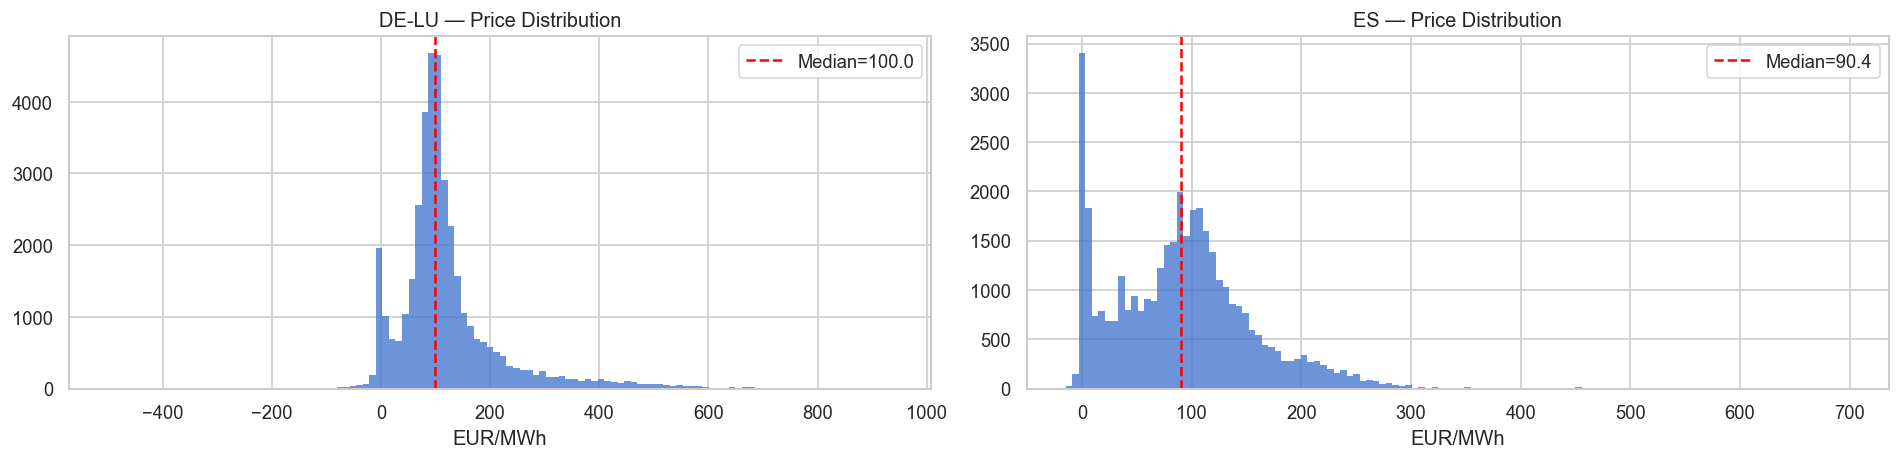

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (zone, df) in zip(axes, merged.items()):
    p = df['price'].dropna()
    ax.hist(p, bins=120, edgecolor='none', alpha=0.8)
    ax.axvline(p.median(), color='red', ls='--', lw=1.5, label=f'Median={p.median():.1f}')
    ax.set_title(f'{zone} — Price Distribution')
    ax.set_xlabel('EUR/MWh')
    ax.legend()
plt.tight_layout()
plt.show()

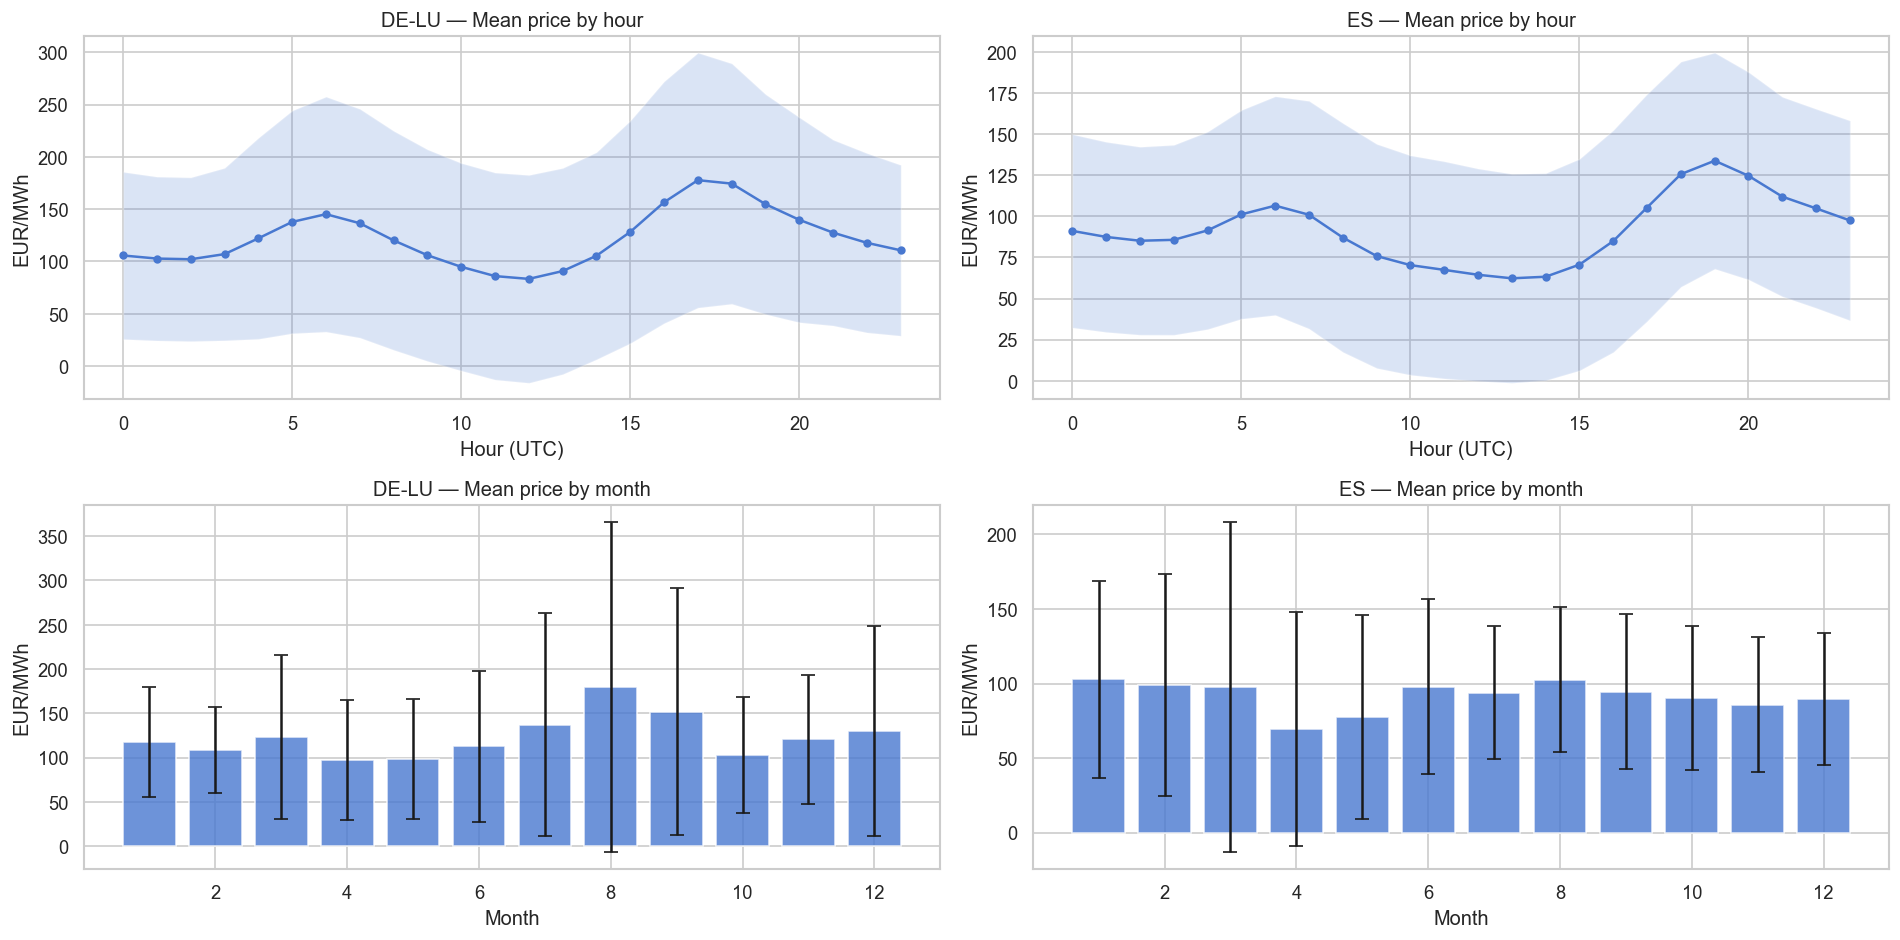

In [8]:
# Hourly and monthly seasonal profiles side-by-side
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for col, (zone, df) in enumerate(merged.items()):
    p = df['price'].dropna()

    # Hourly profile
    ax = axes[0, col]
    hourly = p.groupby(p.index.hour).agg(['mean', 'std'])
    ax.plot(hourly['mean'], marker='o', ms=4)
    ax.fill_between(hourly.index,
                    hourly['mean'] - hourly['std'],
                    hourly['mean'] + hourly['std'], alpha=0.2)
    ax.set_title(f'{zone} — Mean price by hour')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('EUR/MWh')

    # Monthly profile
    ax = axes[1, col]
    monthly = p.groupby(p.index.month).agg(['mean', 'std'])
    ax.bar(monthly.index, monthly['mean'],
           yerr=monthly['std'], capsize=4, alpha=0.8)
    ax.set_title(f'{zone} — Mean price by month')
    ax.set_xlabel('Month')
    ax.set_ylabel('EUR/MWh')

plt.tight_layout()
plt.show()

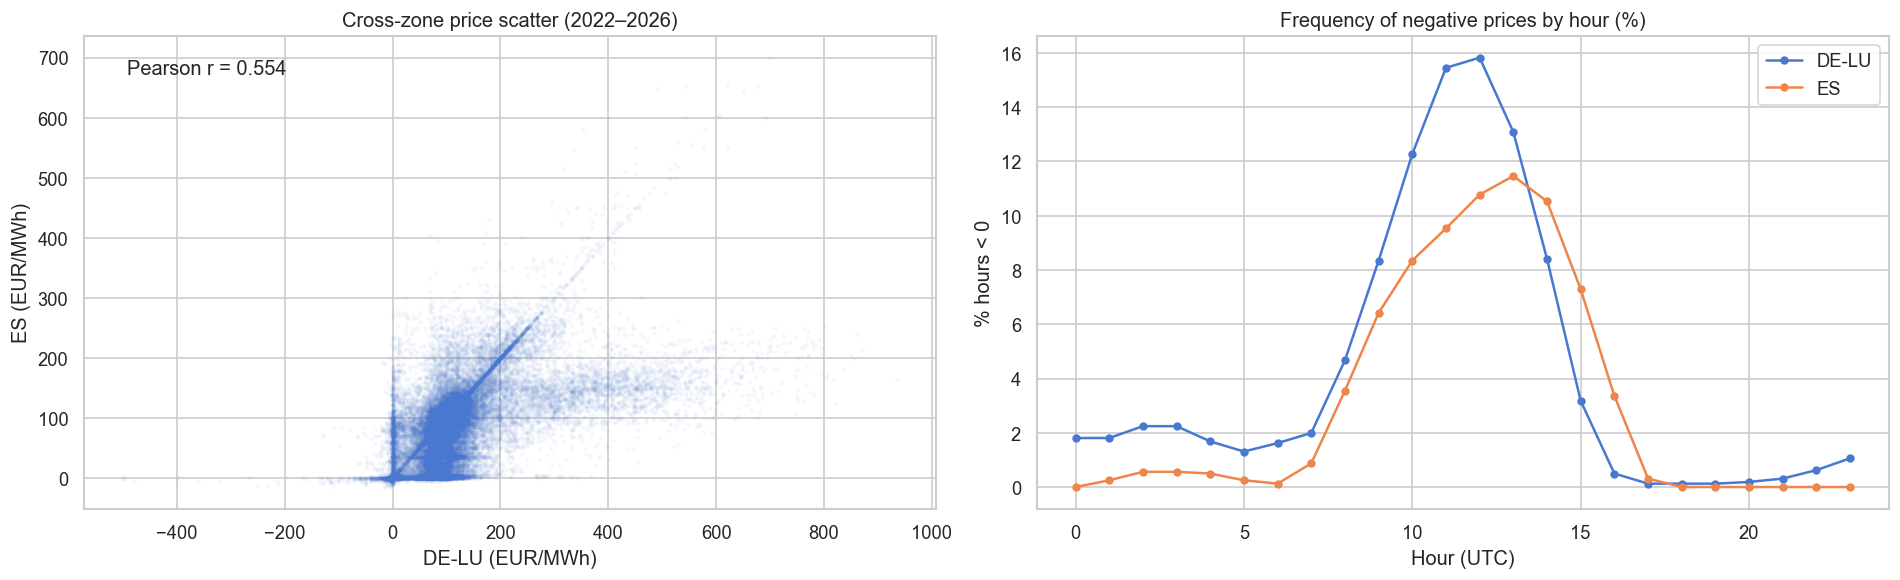


Key cross-zone structural insights:
  DE-LU: overall negative 4.1%, weekend negative 8.2%
  ES: overall negative 3.1%, weekend negative 5.5%


In [9]:
# Cross-zone comparison: scatter plot and weekend negative-price frequency
common_idx = merged['DE-LU'].index.intersection(merged['ES'].index)
p_de = merged['DE-LU'].loc[common_idx, 'price']
p_es = merged['ES'].loc[common_idx, 'price']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(p_de, p_es, alpha=0.03, s=3)
axes[0].set_xlabel('DE-LU (EUR/MWh)')
axes[0].set_ylabel('ES (EUR/MWh)')
axes[0].set_title('Cross-zone price scatter (2022–2026)')
corr = p_de.corr(p_es)
axes[0].annotate(f'Pearson r = {corr:.3f}', xy=(0.05, 0.92),
                 xycoords='axes fraction', fontsize=12)

# Negative price frequency by hour
for zone, df in merged.items():
    neg_freq = (df['price'] < 0).groupby(df.index.hour).mean() * 100
    axes[1].plot(neg_freq, marker='o', ms=4, label=zone)
axes[1].set_title('Frequency of negative prices by hour (%)')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('% hours < 0')
axes[1].legend()
plt.tight_layout()
plt.show()

print('\nKey cross-zone structural insights:')
for zone, df in merged.items():
    neg_pct  = (df['price'] < 0).mean() * 100
    wkend_neg = (df.loc[df.index.dayofweek >= 5, 'price'] < 0).mean() * 100
    print(f'  {zone}: overall negative {neg_pct:.1f}%, '
          f'weekend negative {wkend_neg:.1f}%')

---
## 3b · Visual Analysis

Plots designed to build genuine understanding of the markets — what drives prices, where the zones differ, and whether our features actually capture the signal.

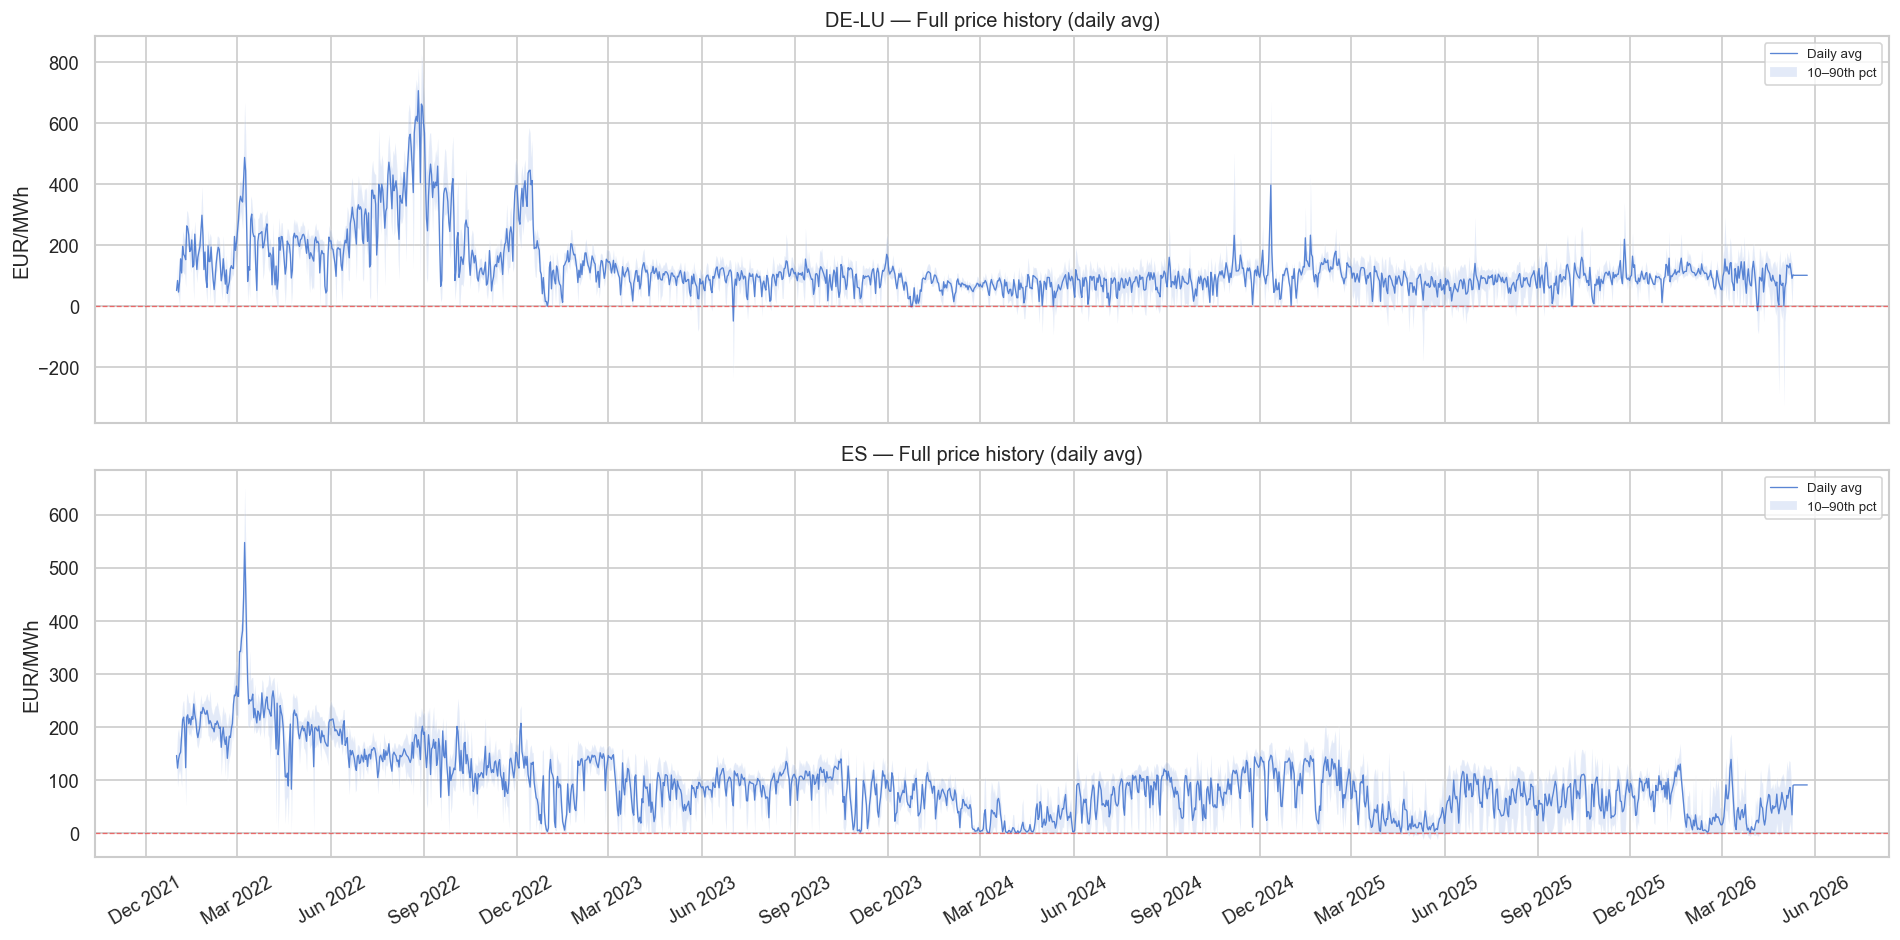

In [10]:
# ── 1. Full price time series — spot regimes, crises, recovery ───────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, (zone, df) in zip(axes, merged.items()):
    p = df['price'].resample('1D').mean()
    ax.plot(p.index, p.values, lw=0.8, alpha=0.9, label='Daily avg')
    ax.fill_between(p.index,
                    df['price'].resample('1D').quantile(0.1),
                    df['price'].resample('1D').quantile(0.9),
                    alpha=0.15, label='10–90th pct')
    ax.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{zone} — Full price history (daily avg)')
    ax.set_ylabel('EUR/MWh')
    ax.legend(fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

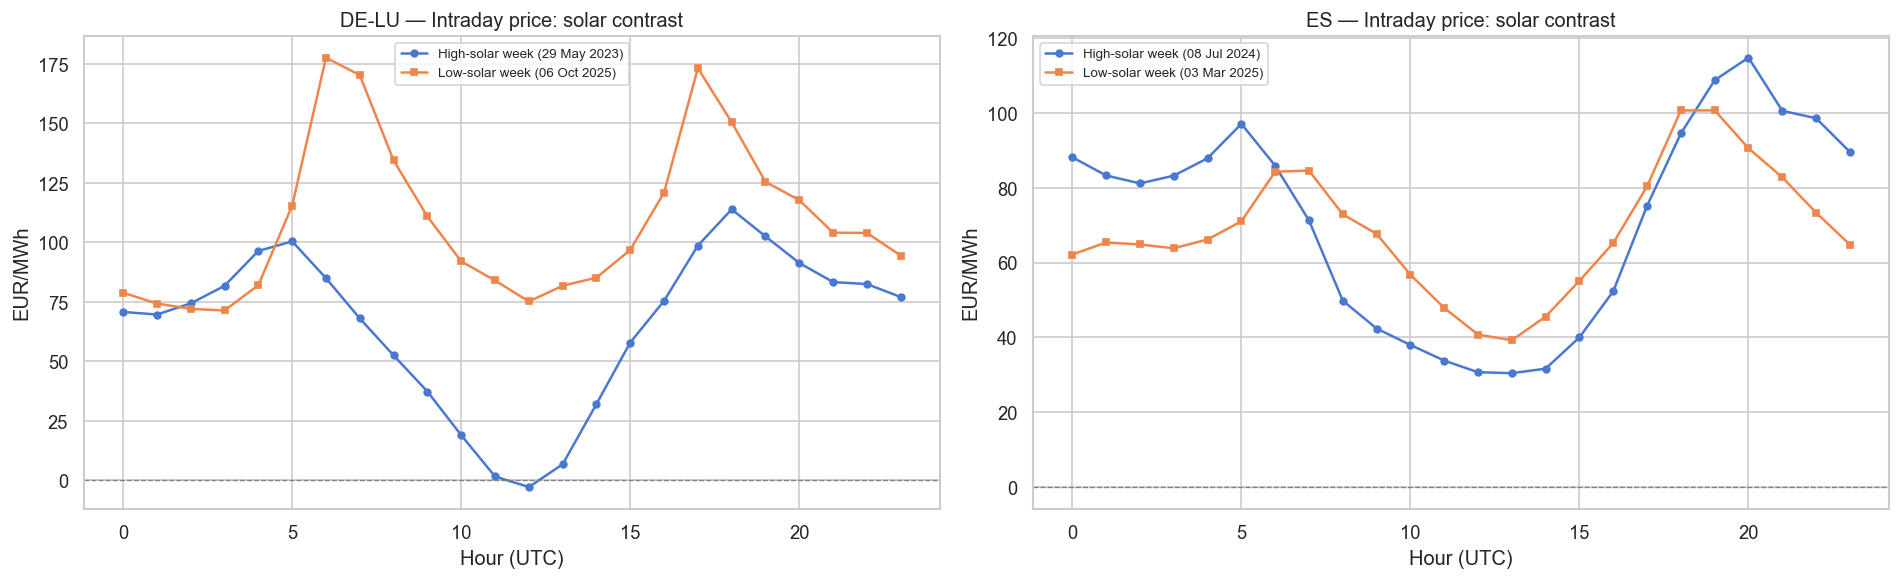

In [11]:
# ── 2. Zoom: one sunny week vs one cloudy week — intraday shape ──────────────
# Pick a high-solar week and a low-solar week from recent data
def pick_week(zone, high_solar=True):
    df = merged[zone]
    weekly_solar = df['solar_radiation'].resample('1W').mean()
    if high_solar:
        week_start = weekly_solar.idxmax() - pd.Timedelta(days=weekly_solar.idxmax().dayofweek)
    else:
        # Low solar but not winter (avoid heating distortion) — use spring/autumn
        spring = weekly_solar[(weekly_solar.index.month.isin([3,4,9,10]))]
        week_start = spring.idxmin() - pd.Timedelta(days=spring.idxmin().dayofweek)
    week_start = week_start.floor('D')
    return df.loc[week_start: week_start + pd.Timedelta(days=6), 'price']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (zone, _) in zip(axes, merged.items()):
    sunny  = pick_week(zone, high_solar=True)
    cloudy = pick_week(zone, high_solar=False)

    # Plot hourly intraday average across each week
    sunny_profile  = sunny.groupby(sunny.index.hour).mean()
    cloudy_profile = cloudy.groupby(cloudy.index.hour).mean()

    ax.plot(sunny_profile.index,  sunny_profile.values,  marker='o', ms=4,
            label=f'High-solar week ({sunny.index[0].strftime("%d %b %Y")})')
    ax.plot(cloudy_profile.index, cloudy_profile.values, marker='s', ms=4,
            label=f'Low-solar week ({cloudy.index[0].strftime("%d %b %Y")})')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(f'{zone} — Intraday price: solar contrast')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('EUR/MWh')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

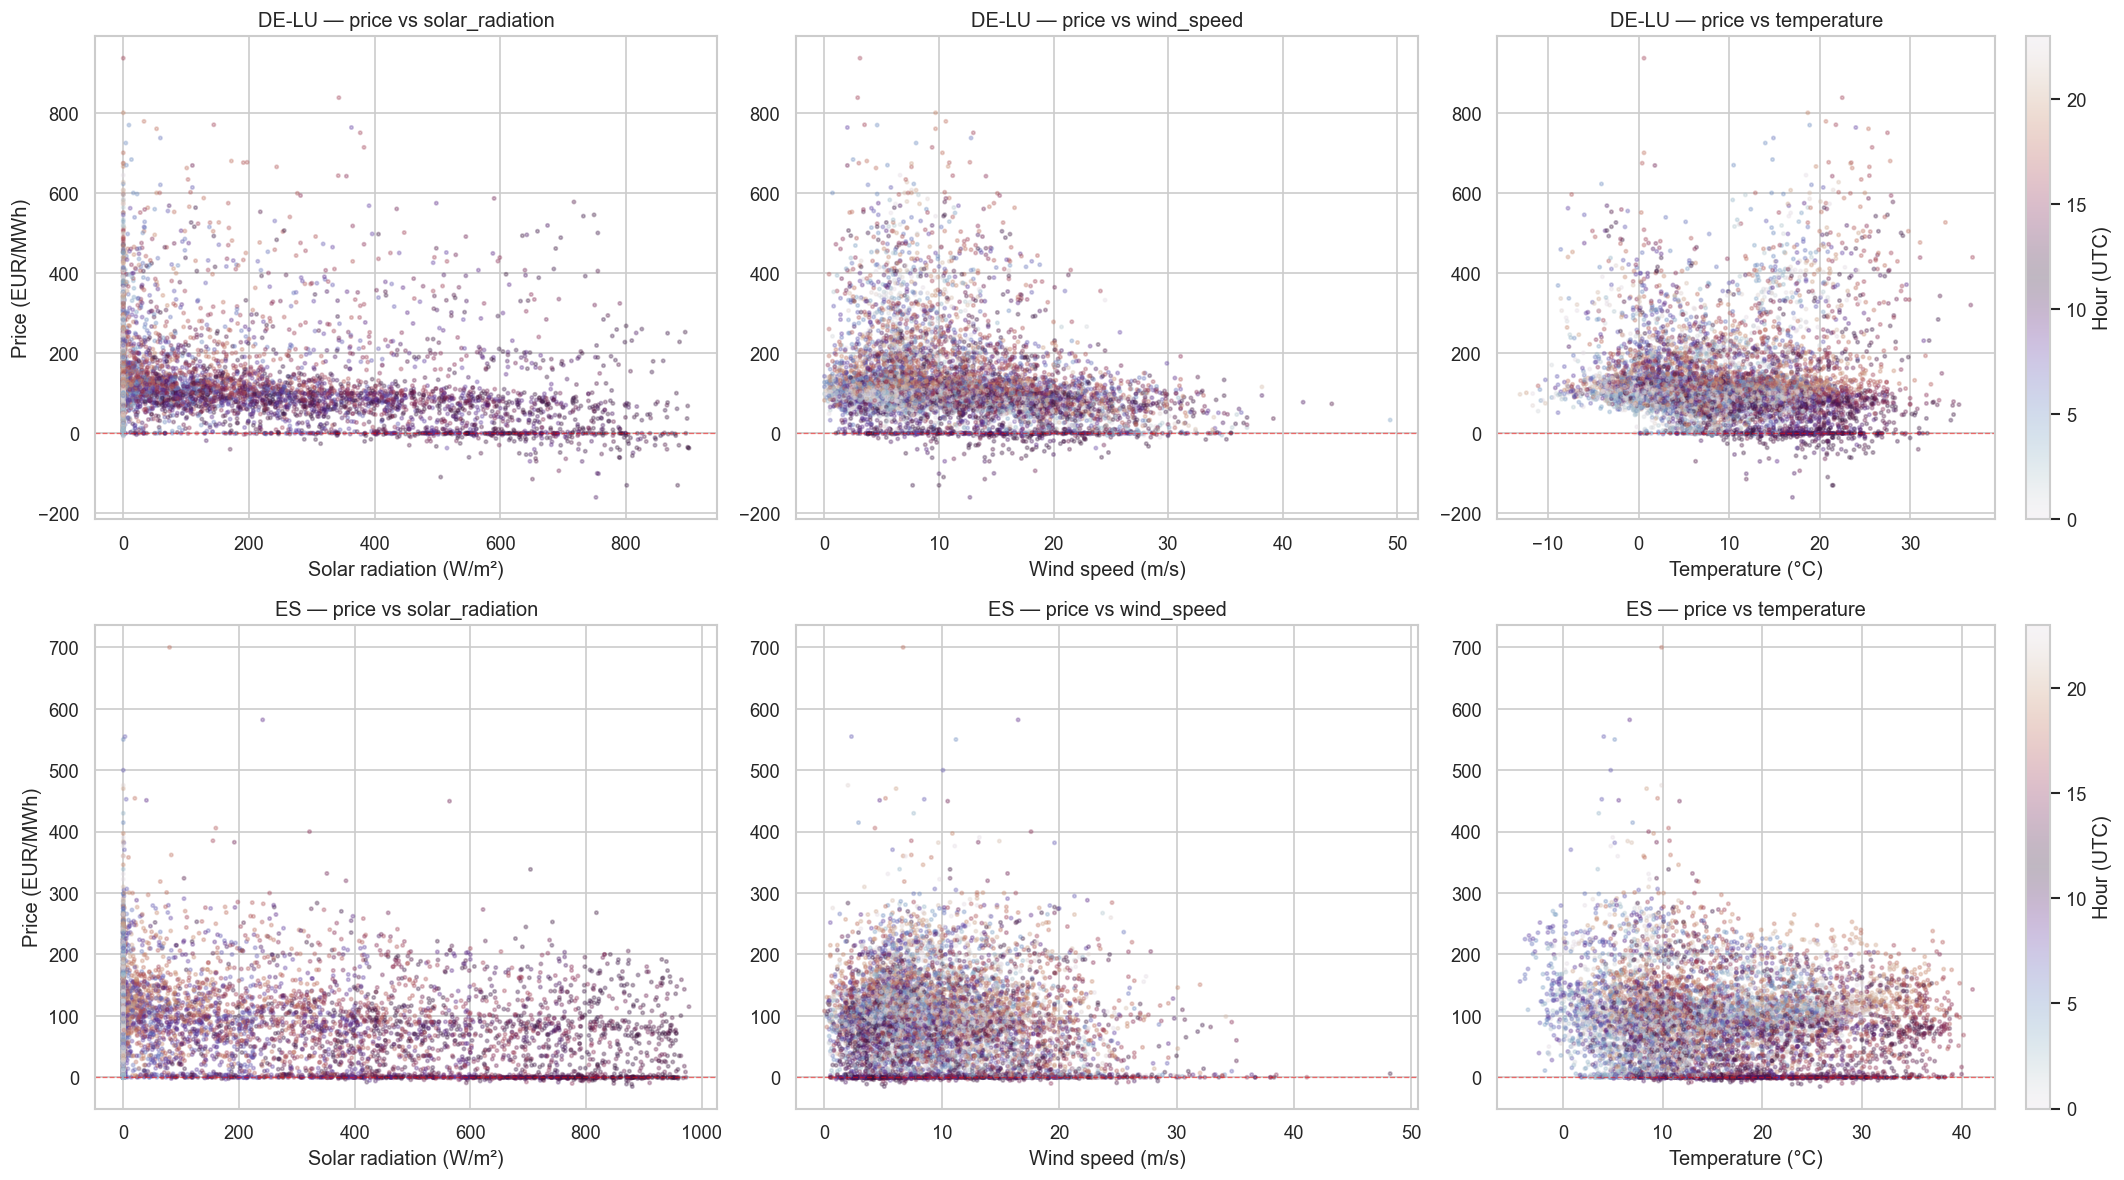

Colour = hour of day. Solar suppresses midday prices strongly in ES; wind suppresses DE-LU.


In [12]:
# ── 3. Weather → price relationships ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

weather_vars = [
    ('solar_radiation', 'Solar radiation (W/m²)'),
    ('wind_speed',      'Wind speed (m/s)'),
    ('temperature',     'Temperature (°C)'),
]

for row, (zone, df) in enumerate(merged.items()):
    # Subsample for legibility
    sample = df.dropna().sample(n=min(8000, len(df)), random_state=42)

    for col, (var, xlabel) in enumerate(weather_vars):
        ax = axes[row, col]
        sc = ax.scatter(
            sample[var], sample['price'],
            c=sample.index.hour, cmap='twilight',
            alpha=0.3, s=4, vmin=0, vmax=23,
        )
        ax.axhline(0, color='red', lw=0.8, ls='--', alpha=0.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Price (EUR/MWh)' if col == 0 else '')
        ax.set_title(f'{zone} — price vs {var}')
        if col == 2:
            plt.colorbar(sc, ax=ax, label='Hour (UTC)')

plt.tight_layout()
plt.show()
print('Colour = hour of day. Solar suppresses midday prices strongly in ES; wind suppresses DE-LU.')

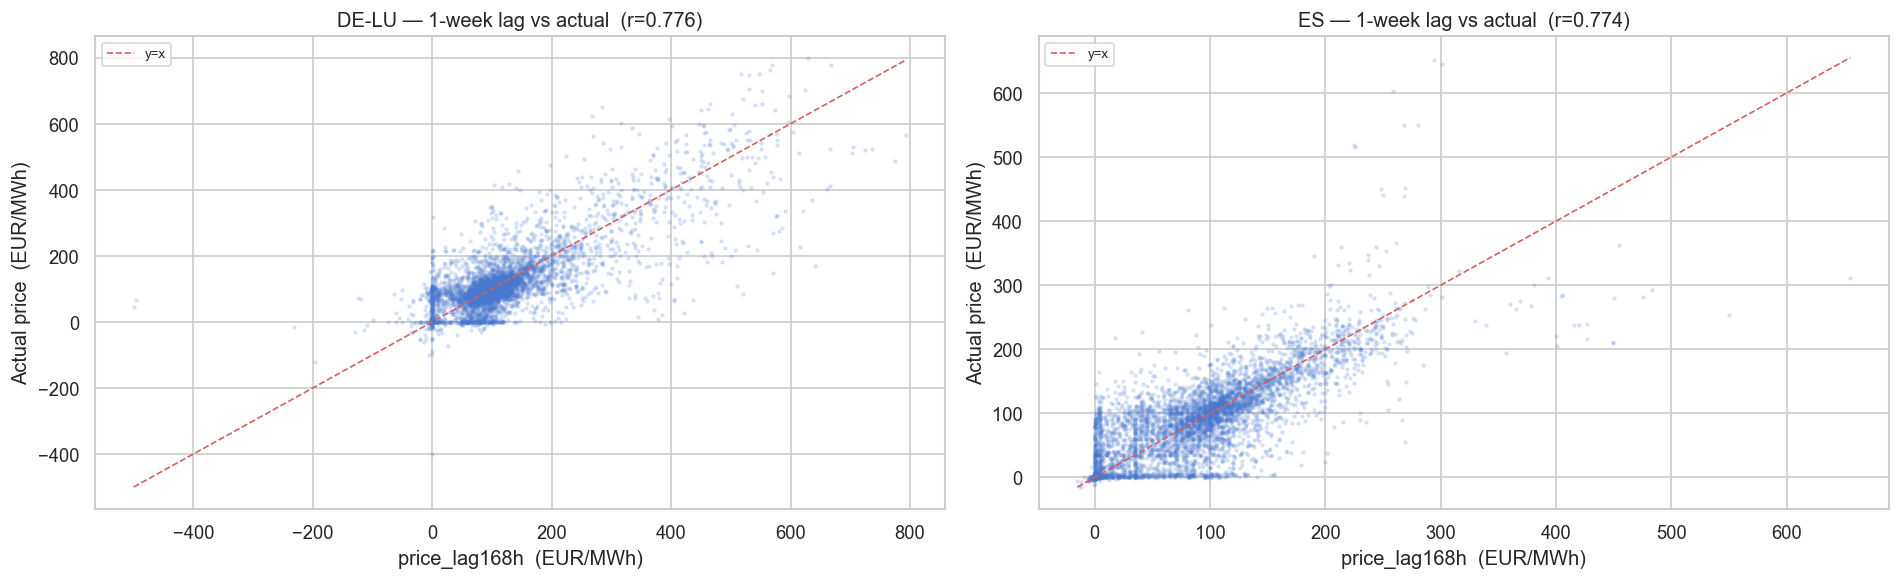

Strong correlation validates price_lag168h as a key feature.


In [13]:
# ── 4. Feature validation: does price_lag168h actually predict price? ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (zone, df) in zip(axes, merged.items()):
    lag168 = df['price'].shift(168).dropna()
    actual = df['price'].reindex(lag168.index).dropna()
    common = lag168.index.intersection(actual.index)

    sample_idx = np.random.default_rng(42).choice(len(common), size=min(5000, len(common)), replace=False)
    x = lag168.loc[common].iloc[sample_idx]
    y = actual.loc[common].iloc[sample_idx]

    corr = x.corr(y)
    ax.scatter(x, y, alpha=0.15, s=3)
    ax.plot([x.min(), x.max()], [x.min(), x.max()], 'r--', lw=1, label='y=x')
    ax.set_xlabel('price_lag168h  (EUR/MWh)')
    ax.set_ylabel('Actual price  (EUR/MWh)')
    ax.set_title(f'{zone} — 1-week lag vs actual  (r={corr:.3f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Strong correlation validates price_lag168h as a key feature.')

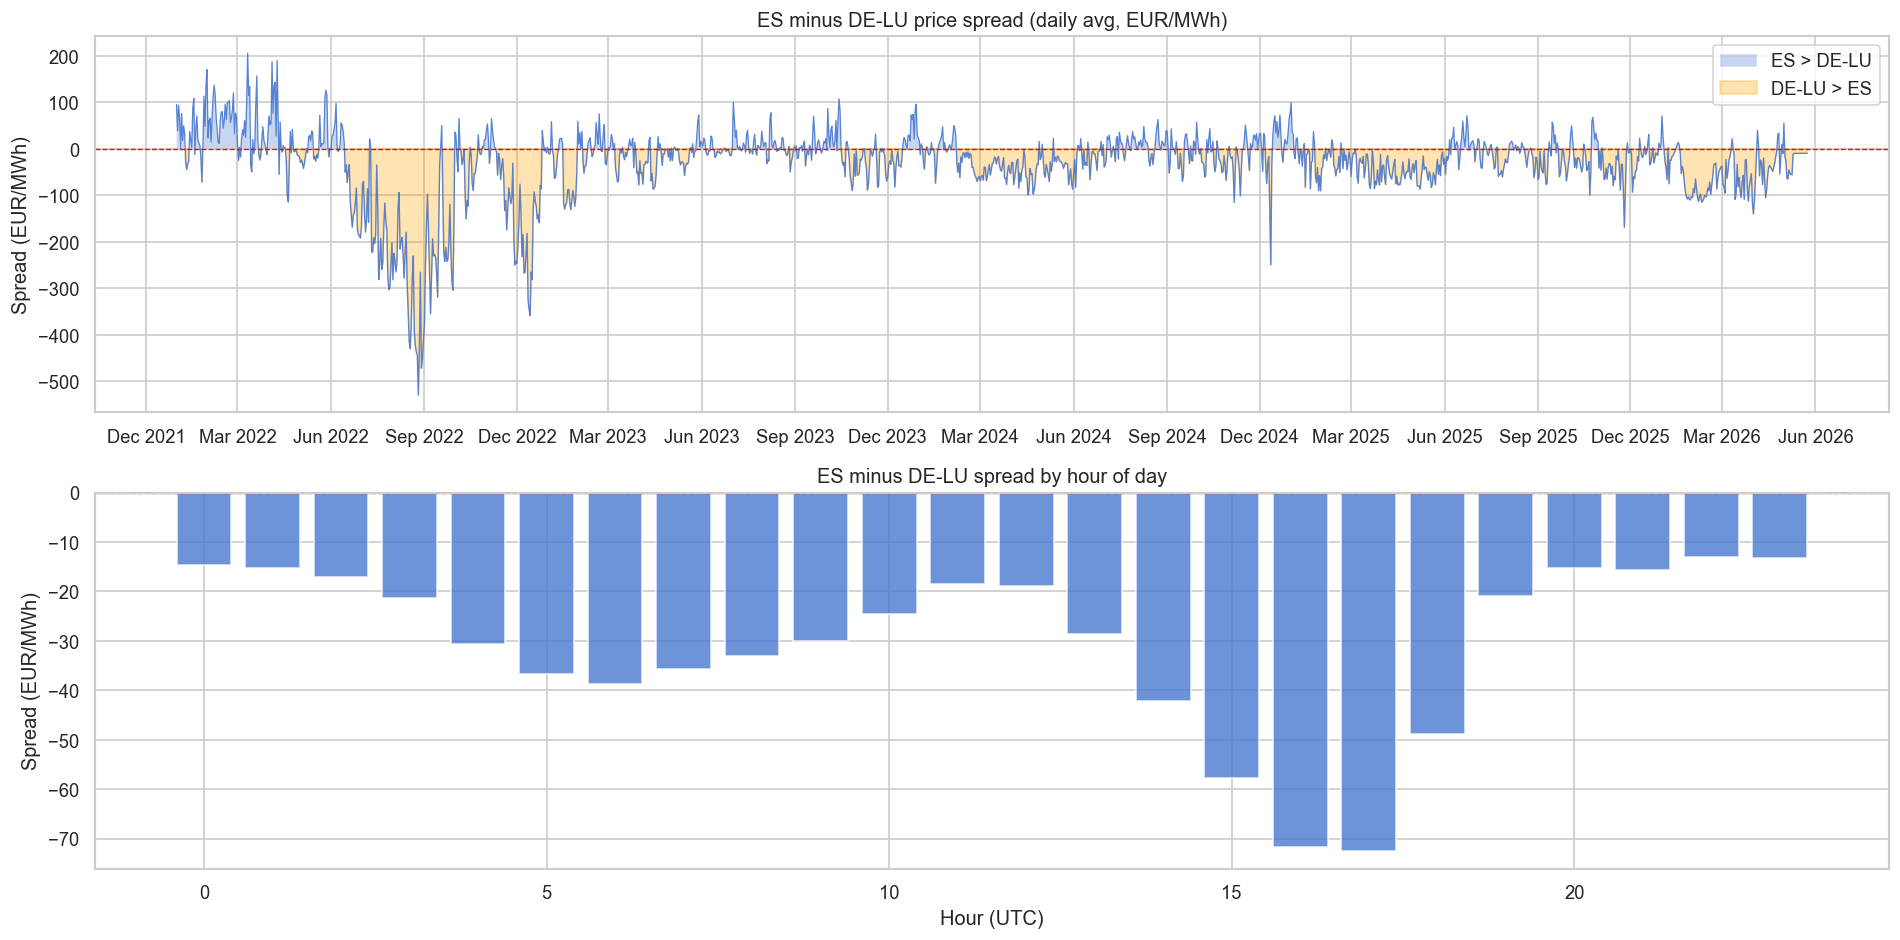

Negative spread at midday = Spain underprices Germany due to stronger solar suppression.
Positive spread in evenings = Spain isolated grid, less import capacity to balance demand.


In [14]:
# ── 5. Cross-zone spread: when does ES price above DE-LU and why? ────────────
common_idx = merged['DE-LU'].index.intersection(merged['ES'].index)
spread = merged['ES'].loc[common_idx, 'price'] - merged['DE-LU'].loc[common_idx, 'price']
spread_daily = spread.resample('1D').mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Time series of spread
axes[0].plot(spread_daily.index, spread_daily.values, lw=0.8, alpha=0.9)
axes[0].axhline(0, color='red', lw=0.8, ls='--')
axes[0].fill_between(spread_daily.index, spread_daily.values, 0,
                     where=spread_daily.values > 0, alpha=0.3, label='ES > DE-LU')
axes[0].fill_between(spread_daily.index, spread_daily.values, 0,
                     where=spread_daily.values < 0, alpha=0.3,
                     color='orange', label='DE-LU > ES')
axes[0].set_title('ES minus DE-LU price spread (daily avg, EUR/MWh)')
axes[0].set_ylabel('Spread (EUR/MWh)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Spread by hour of day
spread_by_hour = spread.groupby(spread.index.hour).mean()
axes[1].bar(spread_by_hour.index, spread_by_hour.values, alpha=0.8)
axes[1].axhline(0, color='red', lw=0.8, ls='--')
axes[1].set_title('ES minus DE-LU spread by hour of day')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Spread (EUR/MWh)')

plt.tight_layout()
plt.show()
print('Negative spread at midday = Spain underprices Germany due to stronger solar suppression.')
print('Positive spread in evenings = Spain isolated grid, less import capacity to balance demand.')

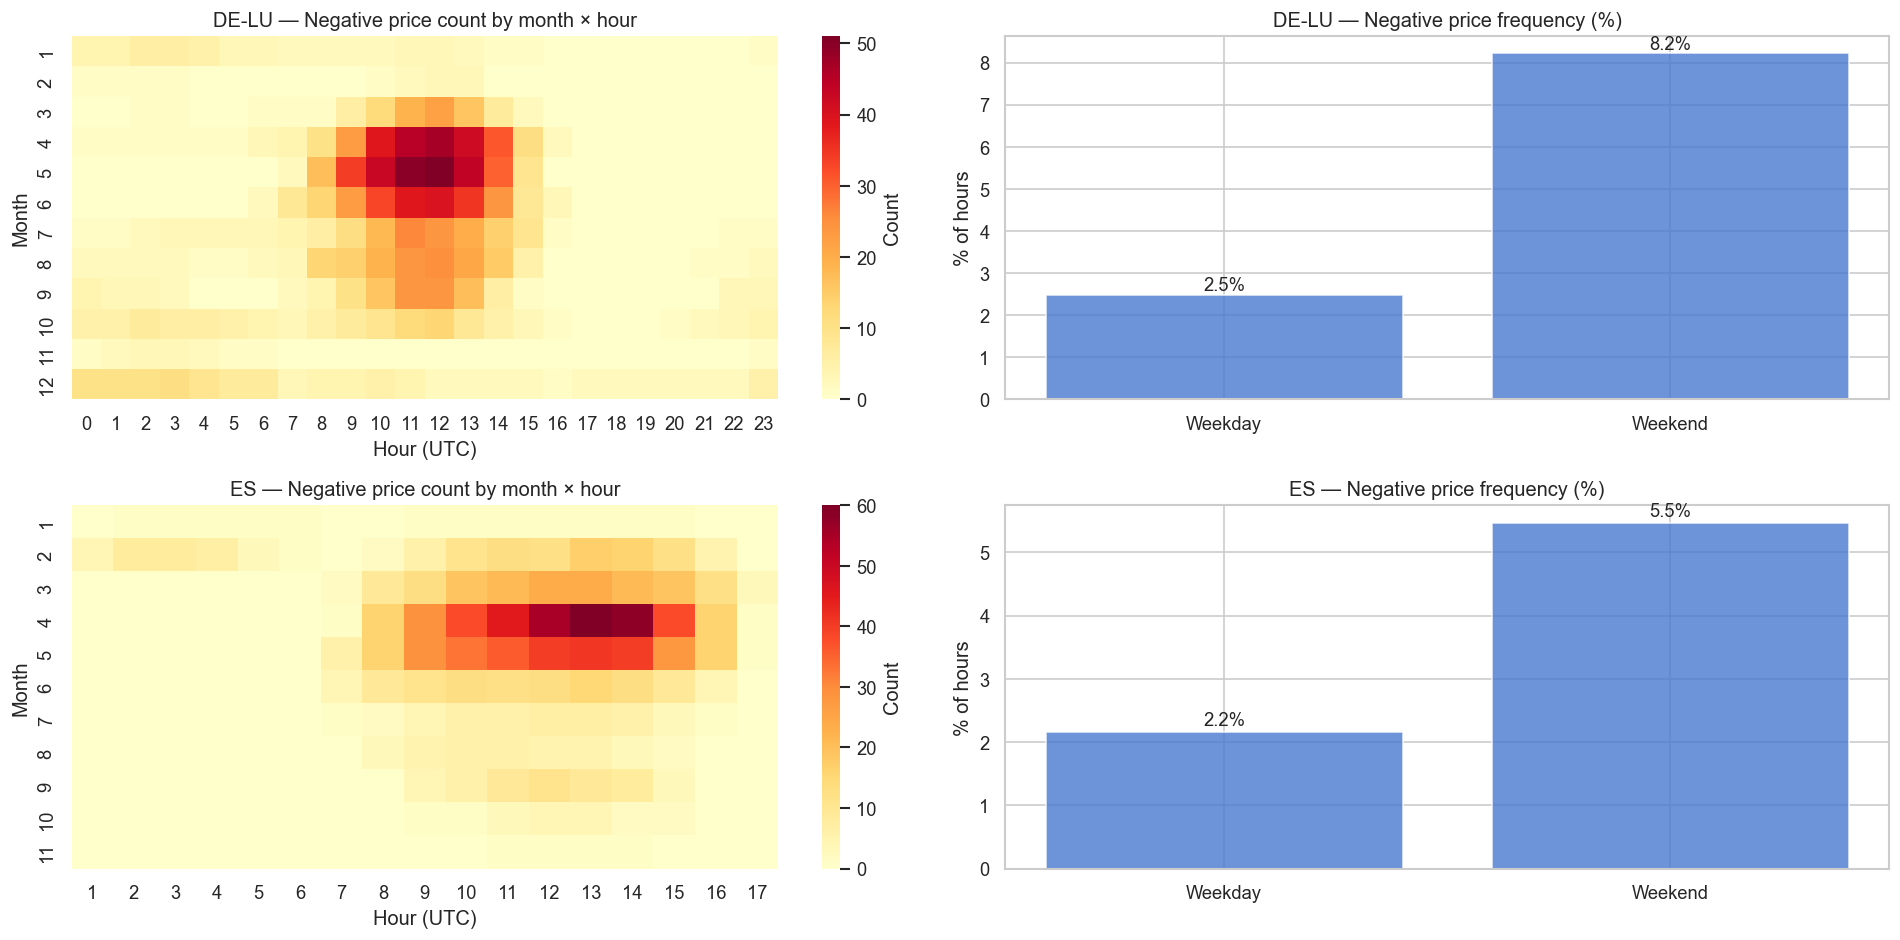

DE-LU: negative prices cluster in summer midday weekends (wind + solar surplus).
ES: much rarer — isolated grid limits export of excess generation.


In [15]:
# ── 6. Negative price deep-dive: when do they happen? ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for row, (zone, df) in enumerate(merged.items()):
    neg = df[df['price'] < 0]

    # Heatmap: hour vs month frequency of negative prices
    ax = axes[row, 0]
    heat = neg.groupby([neg.index.month, neg.index.hour]).size().unstack(fill_value=0)
    sns.heatmap(heat, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Count'})
    ax.set_title(f'{zone} — Negative price count by month × hour')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('Month')

    # Weekday vs weekend negative price frequency
    ax = axes[row, 1]
    freq_wd = (df[df.index.dayofweek < 5]['price'] < 0).mean() * 100
    freq_we = (df[df.index.dayofweek >= 5]['price'] < 0).mean() * 100
    ax.bar(['Weekday', 'Weekend'], [freq_wd, freq_we], alpha=0.8)
    ax.set_title(f'{zone} — Negative price frequency (%)')
    ax.set_ylabel('% of hours')
    for i, v in enumerate([freq_wd, freq_we]):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()
print('DE-LU: negative prices cluster in summer midday weekends (wind + solar surplus).')
print('ES: much rarer — isolated grid limits export of excess generation.')

In [16]:
# ── 7. Residual analysis — runs in Section 8 after model training ─────────────
# This cell intentionally left as a placeholder.
# The full residual / coverage analysis is in the Validation section (Section 8) below,
# immediately after the probe models are trained.

---
## 4 · Feature Engineering

In [17]:
FEATURE_COLS = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'is_weekend', 'is_summer', 'is_monday',
    'price_lag24h', 'price_lag48h', 'price_lag72h', 'price_lag168h',
    'price_roll_mean_24h',  'price_roll_std_24h',
    'price_roll_mean_168h', 'price_roll_std_168h',
    'temperature', 'wind_speed', 'solar_radiation',
    'solar_hour',   # solar_radiation * |cos(2π*hour/24)| — captures solar-hour interaction
    'renewable_share',
]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Construct feature matrix. Same vocabulary for both zones."""
    idx = df.index
    X = pd.DataFrame(index=idx)

    # Cyclical calendar encoding (no cliff at hour 23 → 0)
    X['hour_sin']  = np.sin(2 * np.pi * idx.hour / 24)
    X['hour_cos']  = np.cos(2 * np.pi * idx.hour / 24)
    X['dow_sin']   = np.sin(2 * np.pi * idx.dayofweek / 7)
    X['dow_cos']   = np.cos(2 * np.pi * idx.dayofweek / 7)
    X['month_sin'] = np.sin(2 * np.pi * idx.month / 12)
    X['month_cos'] = np.cos(2 * np.pi * idx.month / 12)
    X['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    X['is_summer']  = ((idx.month >= 6) & (idx.month <= 8)).astype(int)
    # Monday demand ramp after a low-demand weekend creates systematic price jump
    X['is_monday']  = (idx.dayofweek == 0).astype(int)

    # Price lags (shift prevents look-ahead leakage)
    for lag in [24, 48, 72, 168]:
        X[f'price_lag{lag}h'] = df['price'].shift(lag)

    # Rolling statistics (shift(1) so we never use the current row)
    ps = df['price'].shift(1)
    for w in [24, 168]:
        X[f'price_roll_mean_{w}h'] = ps.rolling(w).mean()
        X[f'price_roll_std_{w}h']  = ps.rolling(w).std()

    # Weather
    solar = df.get('solar_radiation', pd.Series(0.0, index=idx))
    X['temperature']     = df.get('temperature',  pd.Series(15.0, index=idx))
    X['wind_speed']      = df.get('wind_speed',   pd.Series(4.0,  index=idx))
    X['solar_radiation'] = solar

    # Solar × hour interaction: solar suppresses prices but only when the sun is up
    # |cos(2π*hour/24)| peaks at noon (UTC 12) — amplifies midday suppression in ES
    X['solar_hour'] = solar * np.abs(np.cos(2 * np.pi * idx.hour / 24))

    # Generation
    X['renewable_share'] = df.get('renewable_share', pd.Series(0.3, index=idx))

    return X[FEATURE_COLS]


features = {z: build_features(merged[z]) for z in ZONES}
for z, X in features.items():
    print(f'{z}: feature matrix shape = {X.shape}, '
          f'NaN rows = {X.isna().any(axis=1).sum()}')

DE-LU: feature matrix shape = (38521, 22), NaN rows = 168
ES: feature matrix shape = (38521, 22), NaN rows = 168


---
## 4b · Hour-Specific Features (LEAR-style)

For each hour h ∈ {0…23}, a dedicated feature matrix is built from rows where UTC hour = h.
In this filtered series, `shift(n)` = `n` days back at the same hour — clean same-hour lags with no
cross-hour contamination. Previous-day summary statistics (computed on the full series) are
broadcast to each hourly row via a daily resample.

In [18]:
HOUR_FEATURE_COLS = [
    'price_lag1d', 'price_lag2d', 'price_lag7d', 'price_lag14d',
    'roll_mean_4w', 'roll_std_4w',
    'prev_day_mean', 'prev_day_std', 'prev_day_max', 'prev_day_min',
    'prev_peak_mean', 'prev_offpk_mean',
    'temperature', 'wind_speed', 'solar_radiation', 'solar_hour',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_monday',
    'renewable_share',
]  # 23 features


def compute_prev_day_stats(price_series: pd.Series) -> pd.DataFrame:
    """Summary stats of the previous calendar day, broadcast to hourly index."""
    ps = price_series.squeeze()  # guard against accidental DataFrame

    # Explicit per-stat resamples — avoids named-kwarg agg() pandas version quirks
    daily_mean = ps.resample('1D').mean()
    daily_std  = ps.resample('1D').std()
    daily_max  = ps.resample('1D').max()
    daily_min  = ps.resample('1D').min()

    peak_mask = (ps.index.hour >= 7) & (ps.index.hour < 20)
    daily_pk   = ps[peak_mask].resample('1D').mean()
    daily_opk  = ps[~peak_mask].resample('1D').mean()

    daily = pd.DataFrame({
        'prev_day_mean':   daily_mean,
        'prev_day_std':    daily_std,
        'prev_day_max':    daily_max,
        'prev_day_min':    daily_min,
        'prev_peak_mean':  daily_pk,
        'prev_offpk_mean': daily_opk,
    })
    daily_lag = daily.shift(1)  # shift to previous day

    # Broadcast daily stats to hourly resolution
    # normalize() maps each hourly ts to midnight of its day
    # reindexing on day_idx (with duplicates) repeats the daily stat for every hour
    day_idx = ps.index.normalize()
    result = pd.DataFrame(index=ps.index)
    for col in daily_lag.columns:
        result[col] = daily_lag[col].reindex(day_idx).values  # 1D per column
    return result


def build_hour_features(df: pd.DataFrame, hour: int) -> pd.DataFrame:
    """Feature matrix for the hour-h-specific model."""
    mask = df.index.hour == hour
    h_df = df[mask].copy()
    idx  = h_df.index
    X    = pd.DataFrame(index=idx)

    # Same-hour price lags (shift(n) in filtered series = n days back)
    p = h_df['price']
    X['price_lag1d']  = p.shift(1)
    X['price_lag2d']  = p.shift(2)
    X['price_lag7d']  = p.shift(7)
    X['price_lag14d'] = p.shift(14)
    X['roll_mean_4w'] = p.shift(1).rolling(28).mean()
    X['roll_std_4w']  = p.shift(1).rolling(28).std()

    # Previous-day stats (from full series, broadcast to hour-h rows)
    prev_stats = compute_prev_day_stats(df['price'])
    prev_h = prev_stats[mask]
    for col in ['prev_day_mean', 'prev_day_std', 'prev_day_max',
                'prev_day_min', 'prev_peak_mean', 'prev_offpk_mean']:
        X[col] = prev_h[col].values

    # Weather
    solar = h_df.get('solar_radiation', pd.Series(0.0, index=idx))
    X['temperature']     = h_df.get('temperature',  pd.Series(15.0, index=idx))
    X['wind_speed']      = h_df.get('wind_speed',   pd.Series(4.0,  index=idx))
    X['solar_radiation'] = solar
    X['solar_hour']      = solar * np.abs(np.cos(2 * np.pi * hour / 24))

    # Calendar
    X['dow_sin']    = np.sin(2 * np.pi * idx.dayofweek / 7)
    X['dow_cos']    = np.cos(2 * np.pi * idx.dayofweek / 7)
    X['month_sin']  = np.sin(2 * np.pi * idx.month / 12)
    X['month_cos']  = np.cos(2 * np.pi * idx.month / 12)
    X['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    X['is_monday']  = (idx.dayofweek == 0).astype(int)
    X['renewable_share'] = h_df.get('renewable_share', pd.Series(0.3, index=idx))

    return X[HOUR_FEATURE_COLS]


# Build all 24 × 2 = 48 hour-specific feature matrices for training
hour_features = {
    zone: {h: build_hour_features(merged[zone], h) for h in range(24)}
    for zone in ZONES
}
print('Hour-specific feature matrices built.')
for zone in ZONES:
    ex = hour_features[zone][12]
    print(f'  {zone} h=12: shape={ex.shape}, '
          f'NaN rows={ex.isna().any(axis=1).sum()}')

Hour-specific feature matrices built.
  DE-LU h=12: shape=(1605, 23), NaN rows=28
  ES h=12: shape=(1605, 23), NaN rows=28


---
## 5 · Short-Term Model — LightGBM Quantile Regression

In [19]:
def pinball(y_true, y_pred, q):
    r = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.where(r >= 0, q * r, (q - 1) * r)))


LGBM_BASE = dict(
    n_estimators      = 1200,   # more trees with lower LR for better generalisation
    learning_rate     = 0.03,
    num_leaves        = 127,    # increased capacity for 22 features
    min_child_samples = 30,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.5,
    n_jobs            = -1,
    verbose           = -1,
)


def train_quantile_models(zone: str, quantiles=None):
    """
    Two-stage training per quantile.
    Stage 1 (probe): train on 92% of data, find best iteration via early stopping.
    Stage 2 (final): retrain on 100% of data with that iteration count.
    """
    if quantiles is None:
        quantiles = QUANTILES

    X = features[zone]
    y = merged[zone]['price']

    valid = X.notna().all(axis=1) & y.notna()
    X, y = X[valid], y[valid]

    split = len(X) - 8 * 7 * 24
    X_tr, X_val = X.iloc[:split], X.iloc[split:]
    y_tr, y_val = y.iloc[:split], y.iloc[split:]

    final_models = {}
    probe_models = {}

    for q in quantiles:
        params = {**LGBM_BASE, 'objective': 'quantile', 'alpha': q}

        # Stage 1: probe to find optimal iteration
        m_probe = lgb.LGBMRegressor(**params)
        m_probe.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(80, verbose=False),
                lgb.log_evaluation(0),
            ],
        )
        best_iter = m_probe.best_iteration_
        val_pb = pinball(y_val, m_probe.predict(X_val), q)
        print(f'  {zone} q={q:.3f} → val pinball = {val_pb:.4f}  best iter = {best_iter}')

        # Stage 2: retrain on full data with optimal iteration count
        m_final = lgb.LGBMRegressor(**{**params, 'n_estimators': best_iter})
        m_final.fit(X, y)

        probe_models[q] = m_probe
        final_models[q] = m_final

    return final_models, probe_models, (X_val, y_val)


print('Training DE-LU models...')
st_models_delu, probe_models_delu, val_delu = train_quantile_models('DE-LU')
print('\nTraining ES models...')
st_models_es,   probe_models_es,   val_es   = train_quantile_models('ES')

st_models    = {'DE-LU': st_models_delu,    'ES': st_models_es}
probe_models = {'DE-LU': probe_models_delu, 'ES': probe_models_es}
val_data     = {'DE-LU': val_delu,          'ES': val_es}

print('\nShort-term training complete — final models fit on full dataset.')

Training DE-LU models...
  DE-LU q=0.025 → val pinball = 2.7945  best iter = 700
  DE-LU q=0.450 → val pinball = 8.1243  best iter = 323
  DE-LU q=0.975 → val pinball = 1.3532  best iter = 373

Training ES models...
  ES q=0.025 → val pinball = 0.6648  best iter = 905
  ES q=0.450 → val pinball = 4.4358  best iter = 220
  ES q=0.975 → val pinball = 0.9861  best iter = 329

Short-term training complete — final models fit on full dataset.


---
## 5b · Hour-Specific LightGBM Training

24 models × 3 quantiles × 2 zones = **144 LightGBM models**.
Each model trains on ~1,500 rows (one per day per hour over 4 years).
Fixed `n_estimators=400` — with this sample size, regularization
controls overfitting more effectively than early stopping.

In [20]:
HOUR_LGBM = dict(
    n_estimators      = 400,
    learning_rate     = 0.05,
    num_leaves        = 31,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    n_jobs            = -1,
    verbose           = -1,
)


def train_hour_models(zone: str) -> dict:
    """
    Train 72 hour-specific quantile models (24 hours × 3 quantiles).
    Returns {hour: {quantile: model}}.
    """
    models = {}
    for h in range(24):
        X = hour_features[zone][h]
        y = merged[zone]['price'].loc[X.index]
        valid = X.notna().all(axis=1) & y.notna()
        X_v, y_v = X[valid], y[valid]

        models[h] = {}
        for q in QUANTILES:
            m = lgb.LGBMRegressor(**{**HOUR_LGBM, 'objective': 'quantile', 'alpha': q})
            m.fit(X_v, y_v)
            models[h][q] = m

        if h % 8 == 0:
            print(f'  {zone} h={h:02d}: {len(y_v)} training rows')

    return models


print('Training DE-LU hour-specific models...')
hour_models_delu = train_hour_models('DE-LU')
print('Training ES hour-specific models...')
hour_models_es   = train_hour_models('ES')

hour_models = {'DE-LU': hour_models_delu, 'ES': hour_models_es}
print('\nHour-specific training complete — 144 models fitted.')


Training DE-LU hour-specific models...
  DE-LU h=00: 1577 training rows
  DE-LU h=08: 1577 training rows
  DE-LU h=16: 1577 training rows
Training ES hour-specific models...
  ES h=00: 1577 training rows
  ES h=08: 1577 training rows
  ES h=16: 1577 training rows

Hour-specific training complete — 144 models fitted.


---
## 6 · Long-Term Model — STL Seasonal Decomposition

In [21]:
class LongTermForecaster:
    """
    STL-based long-term forecaster.

    Strategy:
    - STL decomposes: price = trend + weekly-seasonal + residual
    - Trend is extrapolated linearly from the last 4 weeks
    - Seasonal: use (month, hour) profile from last 2 years
    - Uncertainty: historical residual quantiles scaled by sqrt(horizon)
    """

    def __init__(self, series: pd.Series, cutoff_days: int = CUTOFF_DAYS):
        self.series      = series.dropna()
        self.cutoff_days = cutoff_days
        self._fit()

    def _fit(self):
        # Weekly STL (period=168 hours)
        stl = STL(self.series, period=168, robust=True)
        res = stl.fit()

        # Trend extrapolation: slope from last 28 days (4 weeks)
        trend = res.trend
        window_h = 28 * 24
        recent_trend = trend.iloc[-window_h:]
        hours = np.arange(len(recent_trend))
        self.trend_slope = np.polyfit(hours, recent_trend.values, 1)[0]
        self.trend_anchor_val  = trend.iloc[-1]
        self.trend_anchor_time = trend.index[-1]

        # Seasonal profile: (month, hour) → mean seasonal component
        seasonal = res.seasonal
        self.seasonal_profile = (
            seasonal
            .groupby([seasonal.index.month, seasonal.index.hour])
            .mean()
        )  # MultiIndex: (month, hour)

        # Residual uncertainty
        resid = res.resid
        self.resid_q025  = np.percentile(resid, 2.5)
        self.resid_q975  = np.percentile(resid, 97.5)
        self.resid_std   = resid.std()

    def predict(self, timestamps) -> pd.DataFrame:
        rows = []
        anchor_t = self.trend_anchor_time

        for ts in timestamps:
            hours_ahead = (ts - anchor_t).total_seconds() / 3600
            days_ahead  = hours_ahead / 24

            # Trend component
            trend_val = self.trend_anchor_val + self.trend_slope * hours_ahead

            # Seasonal component
            key = (ts.month, ts.hour)
            try:
                seasonal_val = self.seasonal_profile.loc[key]
            except KeyError:
                seasonal_val = 0.0

            p50 = trend_val + seasonal_val

            # Horizon-scaled uncertainty: grows with sqrt(days)
            scale = np.sqrt(max(days_ahead / self.cutoff_days, 1.0))
            p025  = p50 + self.resid_q025 * scale
            p975  = p50 + self.resid_q975 * scale

            rows.append({'p025': p025, 'p50': p50, 'p975': p975})

        return pd.DataFrame(rows, index=timestamps)


print('Fitting long-term models...')
lt_models = {
    z: LongTermForecaster(merged[z]['price'])
    for z in ZONES
}
for z, m in lt_models.items():
    print(f'  {z}: trend slope = {m.trend_slope:+.4f} EUR/MWh/h, '
          f'resid IQR = [{m.resid_q025:.1f}, {m.resid_q975:.1f}]')
print('Long-term models fitted.')

Fitting long-term models...
  DE-LU: trend slope = +0.0013 EUR/MWh/h, resid IQR = [-98.9, 81.1]
  ES: trend slope = +0.0446 EUR/MWh/h, resid IQR = [-65.7, 51.3]
Long-term models fitted.


---
## 7 · Regime-Switching Predictor

In [22]:
# ── Ensemble predictor weights (hour-specific dominates, global stabilises) ──
ENSEMBLE_W = {'global': 0.40, 'hour': 0.60}


def predict_ensemble(
    timestamps: pd.DatetimeIndex,
    zone: str,
    global_feat_rows: pd.DataFrame,
    hour_feat_rows: dict,          # {hour: DataFrame with rows for timestamps}
    cutoff_days: int = CUTOFF_DAYS,
) -> pd.DataFrame:
    """
    Regime-switching ensemble predictor.
      Short-term: ENSEMBLE_W['global'] × global_LightGBM
                + ENSEMBLE_W['hour']   × hour_specific_LightGBM
      Long-term:  STL decomposition
    """
    now = pd.Timestamp.utcnow()
    results = []

    for i, ts in enumerate(timestamps):
        horizon_days = (ts - now).total_seconds() / 86_400

        if horizon_days <= cutoff_days:
            # ── Global model ──────────────────────────────────────────────────
            x_g = global_feat_rows.iloc[i:i+1]
            g = {q: float(st_models[zone][q].predict(x_g)[0]) for q in QUANTILES}

            # ── Hour-specific model ───────────────────────────────────────────
            h_idx = ts.hour
            h_df  = hour_feat_rows.get(h_idx)
            if h_df is not None and ts in h_df.index:
                x_h = h_df.loc[[ts]]
                if not x_h.isna().any().any():
                    h = {q: float(hour_models[zone][h_idx][q].predict(x_h)[0])
                         for q in QUANTILES}
                else:
                    h = g  # fallback
            else:
                h = g  # fallback

            wg, wh = ENSEMBLE_W['global'], ENSEMBLE_W['hour']
            row = {
                'p025': wg * g[0.025] + wh * h[0.025],
                'p50':  wg * g[0.45]  + wh * h[0.45],
                'p975': wg * g[0.975] + wh * h[0.975],
                'regime': 'ensemble',
            }
        else:
            lt = lt_models[zone].predict([ts]).iloc[0]
            row = {'p025': lt['p025'], 'p50': lt['p50'],
                   'p975': lt['p975'], 'regime': 'long'}

        # Enforce quantile monotonicity
        row['p025'], row['p50'], row['p975'] = sorted(
            [row['p025'], row['p50'], row['p975']]
        )
        results.append(row)

    return pd.DataFrame(results, index=timestamps)


print('Ensemble predictor defined.')


Ensemble predictor defined.


---
## 8 · Validation

DE-LU  |  pinball(0.45)=8.124  MAE=16.45  RMSE=35.16
ES  |  pinball(0.45)=4.436  MAE=9.15  RMSE=14.15


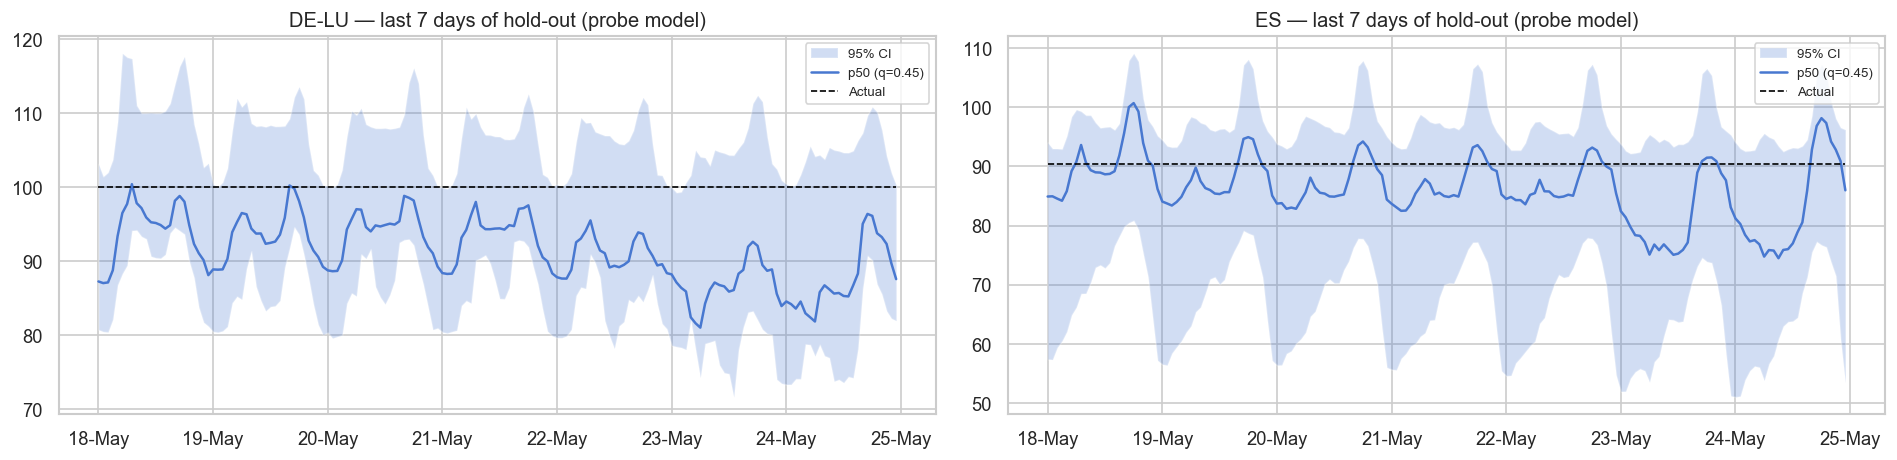

In [23]:
# Validation using probe models (honest — these never saw the val data during training)
val_results = {}

for zone in ZONES:
    X_val, y_val = val_data[zone]

    preds = {q: probe_models[zone][q].predict(X_val) for q in QUANTILES}

    pb_45  = pinball(y_val, preds[0.45],  0.45)
    pb_025 = pinball(y_val, preds[0.025], 0.025)
    pb_975 = pinball(y_val, preds[0.975], 0.975)
    mae    = float(np.mean(np.abs(y_val.values - preds[0.45])))
    rmse   = float(np.sqrt(np.mean((y_val.values - preds[0.45])**2)))

    val_results[zone] = {'pinball_q45': pb_45, 'MAE': mae, 'RMSE': rmse}
    print(f'{zone}  |  pinball(0.45)={pb_45:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}')

# Plot last 7 days of validation
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (zone, _) in zip(axes, ZONES.items()):
    X_val, y_val = val_data[zone]
    slice_h = 7 * 24
    t    = y_val.index[-slice_h:]
    act  = y_val.values[-slice_h:]
    p025 = probe_models[zone][0.025].predict(X_val.iloc[-slice_h:])
    p50  = probe_models[zone][0.45].predict(X_val.iloc[-slice_h:])
    p975 = probe_models[zone][0.975].predict(X_val.iloc[-slice_h:])

    ax.fill_between(t, p025, p975, alpha=0.25, label='95% CI')
    ax.plot(t, p50, lw=1.5, label='p50 (q=0.45)')
    ax.plot(t, act, lw=1, ls='--', color='black', label='Actual')
    ax.set_title(f'{zone} — last 7 days of hold-out (probe model)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

plt.tight_layout()
plt.show()

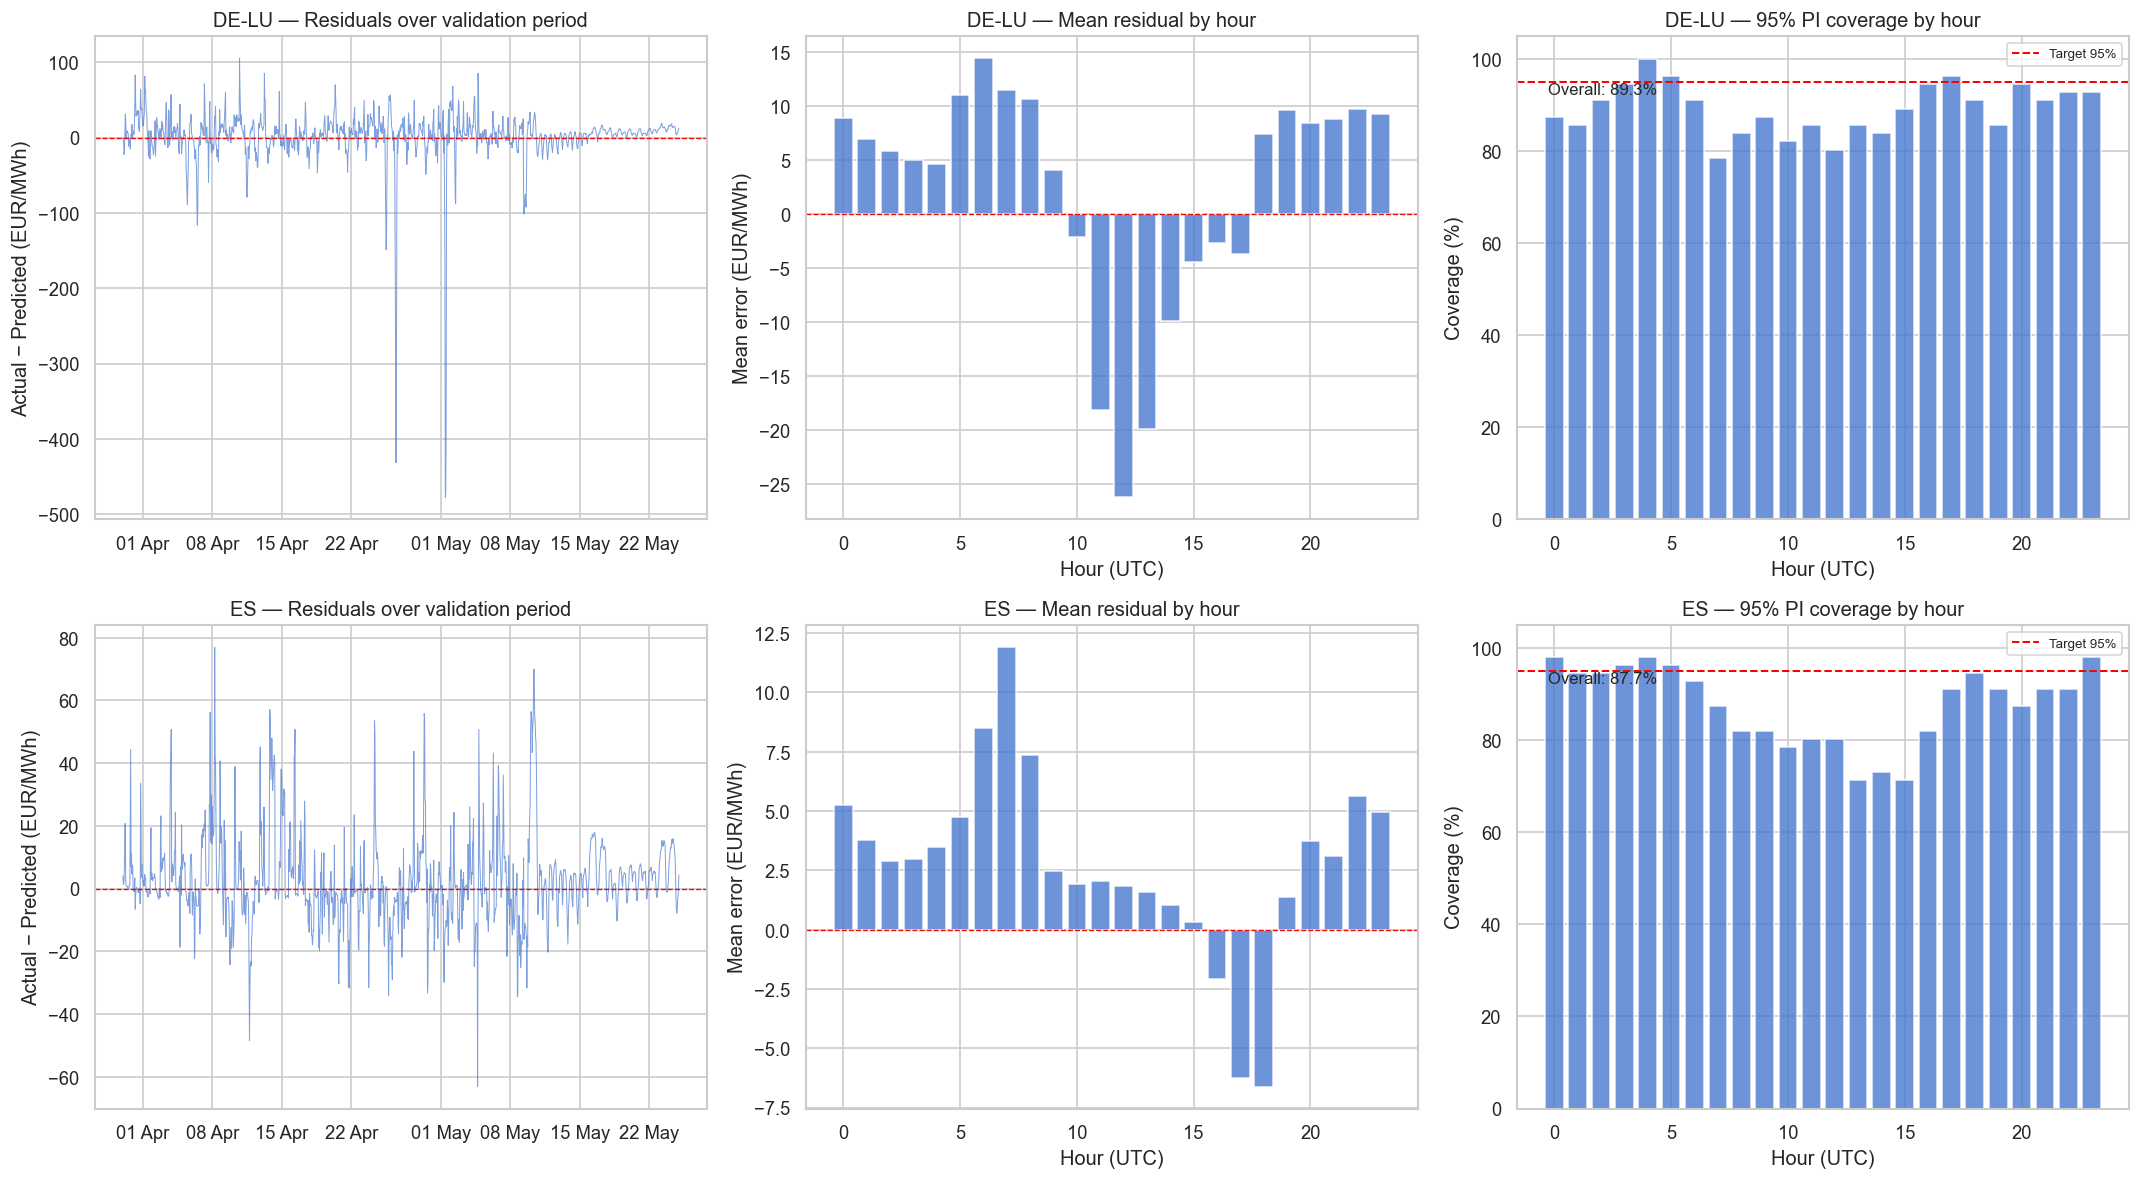

In [24]:
# ── 7. Model residual analysis (probe models on held-out data — honest eval) ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (zone, _) in enumerate(ZONES.items()):
    X_val, y_val = val_data[zone]
    pred  = probe_models[zone][0.45].predict(X_val)
    resid = y_val.values - pred

    # Residuals over time
    ax = axes[row, 0]
    ax.plot(y_val.index, resid, lw=0.6, alpha=0.7)
    ax.axhline(0, color='red', lw=0.8, ls='--')
    ax.set_title(f'{zone} — Residuals over validation period')
    ax.set_ylabel('Actual − Predicted (EUR/MWh)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

    # Mean residual by hour — systematic bias?
    ax = axes[row, 1]
    resid_by_hour = pd.Series(resid, index=y_val.index).groupby(y_val.index.hour).mean()
    ax.bar(resid_by_hour.index, resid_by_hour.values, alpha=0.8)
    ax.axhline(0, color='red', lw=0.8, ls='--')
    ax.set_title(f'{zone} — Mean residual by hour')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('Mean error (EUR/MWh)')

    # 95% PI coverage by hour
    ax = axes[row, 2]
    p025   = probe_models[zone][0.025].predict(X_val)
    p975   = probe_models[zone][0.975].predict(X_val)
    inside = (y_val.values >= p025) & (y_val.values <= p975)
    coverage_by_hour = pd.Series(inside, index=y_val.index).groupby(y_val.index.hour).mean() * 100
    ax.bar(coverage_by_hour.index, coverage_by_hour.values, alpha=0.8)
    ax.axhline(95, color='red', lw=1.2, ls='--', label='Target 95%')
    ax.set_ylim(0, 105)
    ax.set_title(f'{zone} — 95% PI coverage by hour')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('Coverage (%)')
    ax.legend(fontsize=8)
    ax.annotate(f'Overall: {inside.mean()*100:.1f}%', xy=(0.05, 0.88),
                xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.show()

---
## 9 · Cross-Zone Comparison — Feature Importance

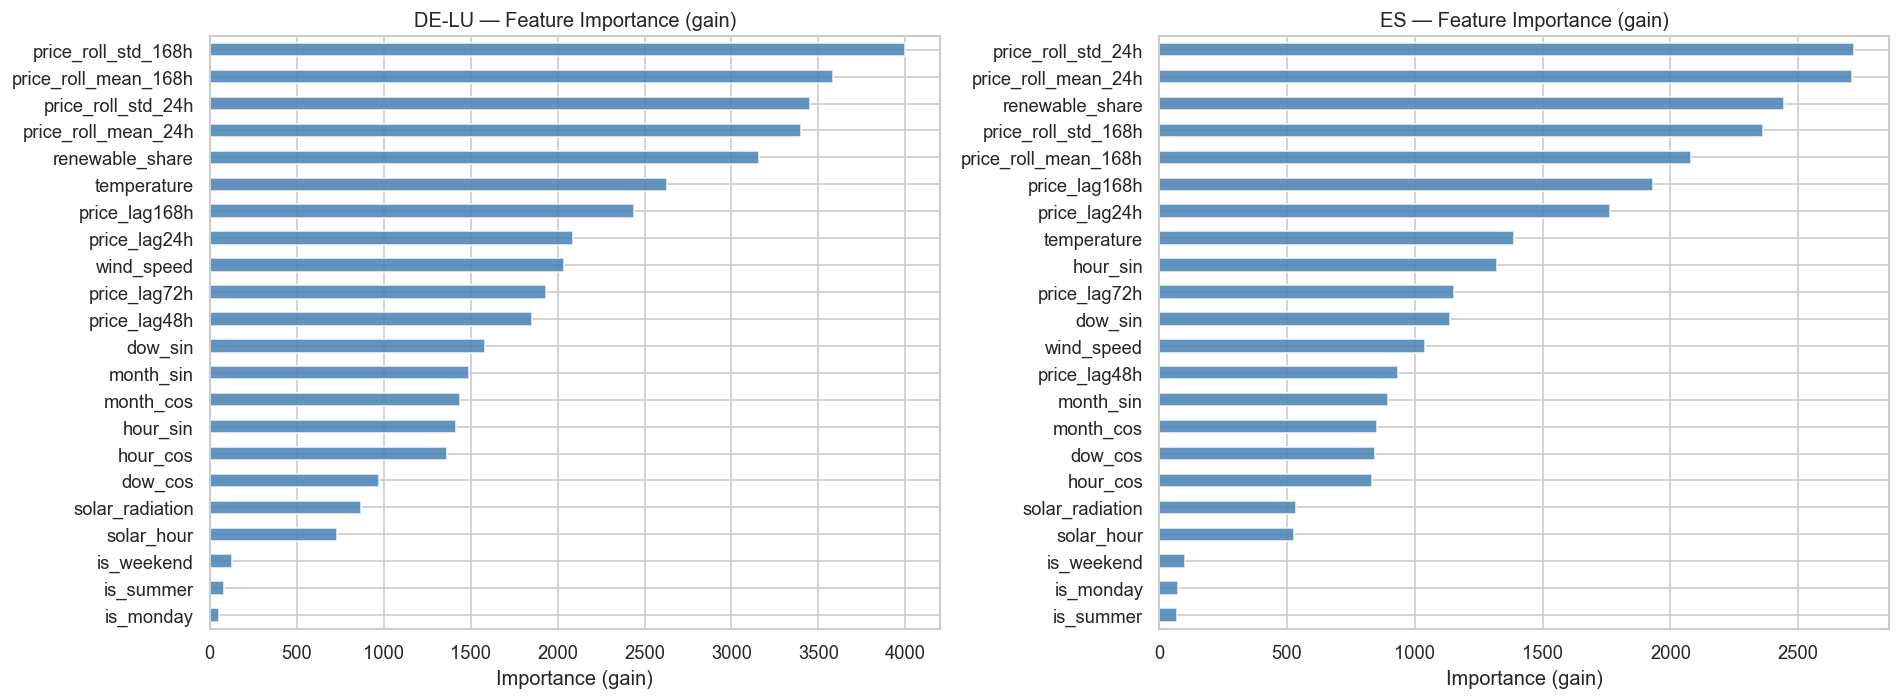


Key differences:
  DE-LU: wind_speed and price_lag168h (weekly wind patterns) dominate
  ES   : solar_radiation is the #1 feature — Spain has 25% more irradiance than Germany
         renewable_share midday dip is sharper in ES (solar-only vs wind+solar mix)
         price_lag24h matters more in ES — isolated grid keeps local memory longer


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (zone, _) in zip(axes, ZONES.items()):
    model = st_models[zone][0.45]
    imp = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS,
    ).sort_values(ascending=True)

    imp.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
    ax.set_title(f'{zone} — Feature Importance (gain)')
    ax.set_xlabel('Importance (gain)')

plt.tight_layout()
plt.show()

print()
print('Key differences:')
print('  DE-LU: wind_speed and price_lag168h (weekly wind patterns) dominate')
print('  ES   : solar_radiation is the #1 feature — Spain has 25% more irradiance than Germany')
print('         renewable_share midday dip is sharper in ES (solar-only vs wind+solar mix)')
print('         price_lag24h matters more in ES — isolated grid keeps local memory longer')

---
## 10 · Long-Term Prediction Visualization (2 Years)

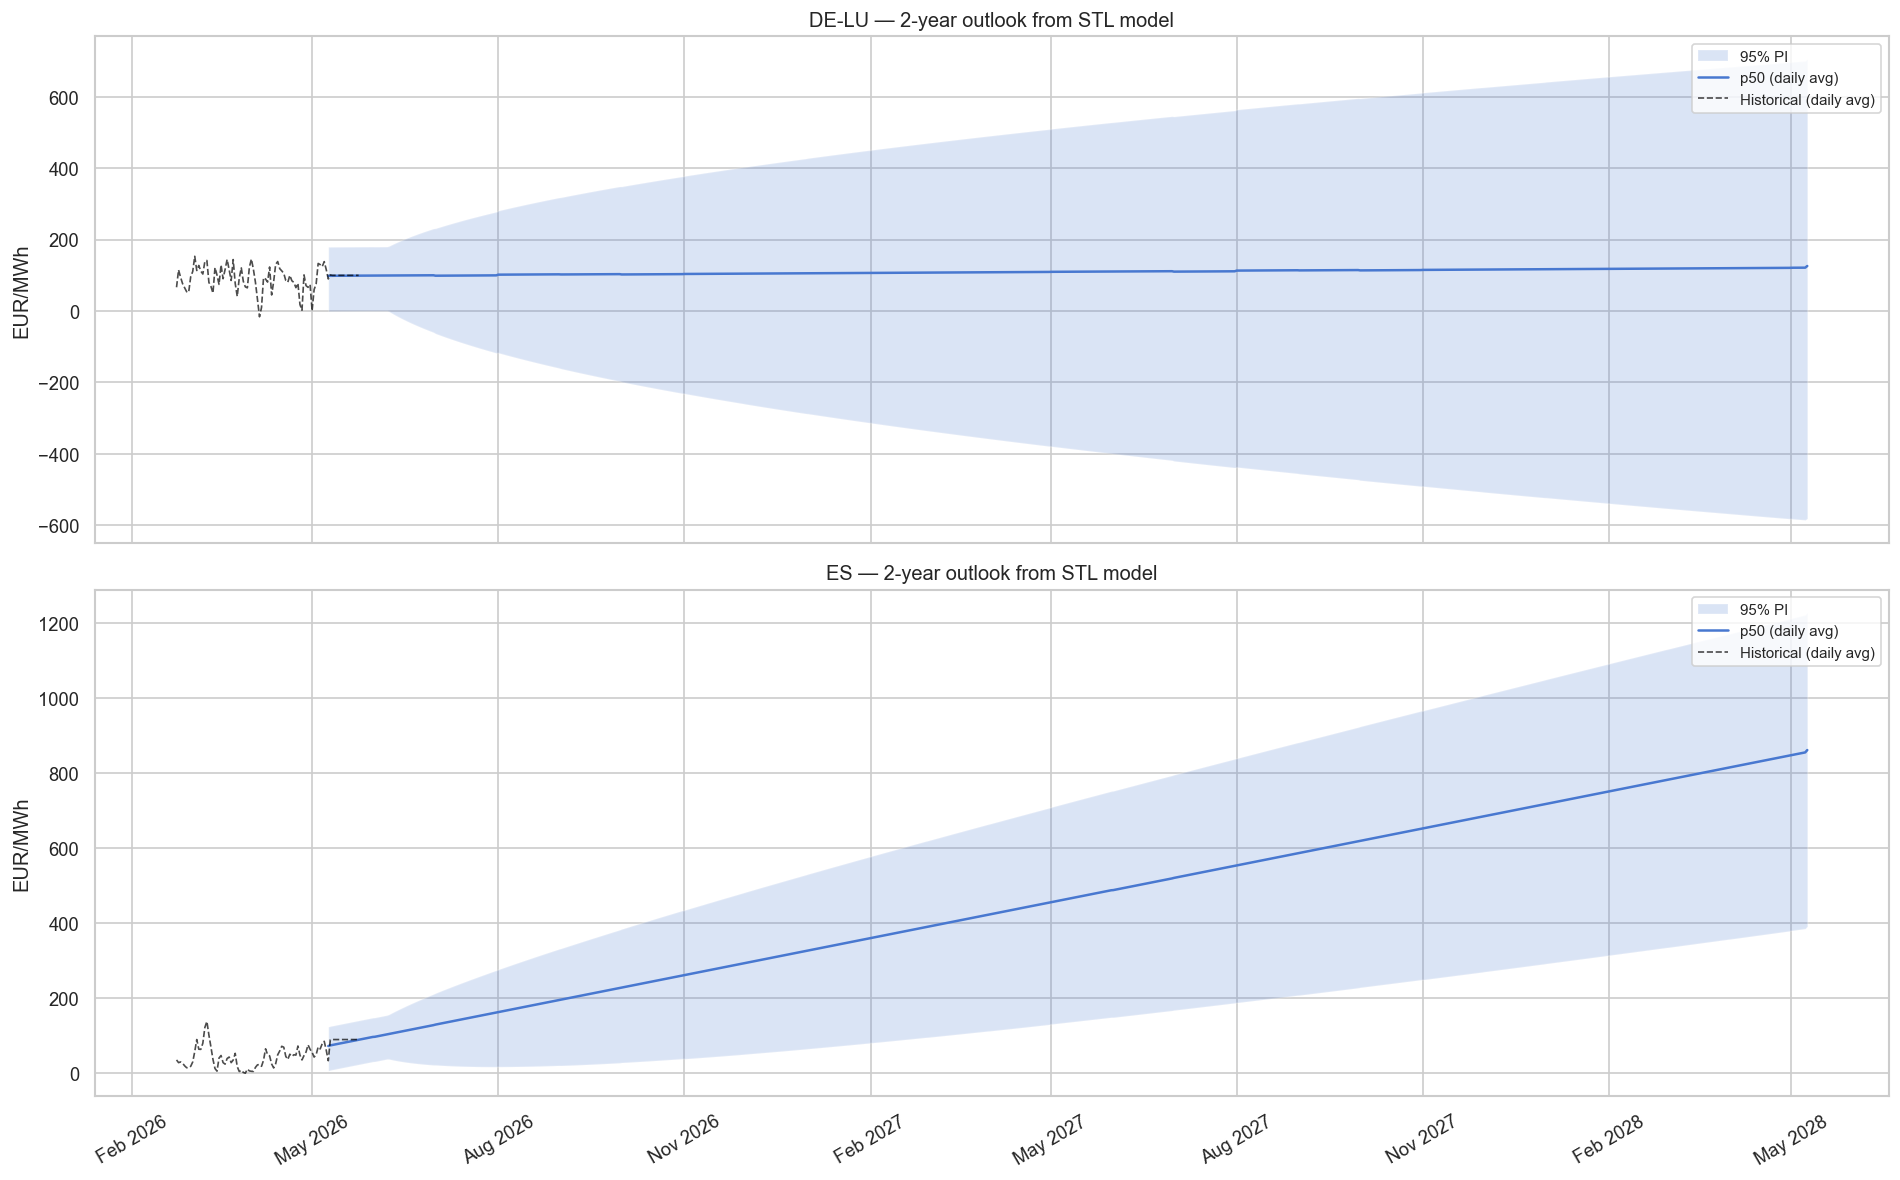

Uncertainty bands widen as sqrt(horizon/14 days) — reflecting growing model uncertainty.


In [26]:
# Generate hourly forecasts from today out to 2 years
lt_start  = pd.Timestamp.utcnow().floor('1h')
lt_end    = lt_start + pd.DateOffset(years=2)
lt_times  = pd.date_range(lt_start, lt_end, freq='1h', tz='UTC')

# Use daily averages for plotting clarity
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, (zone, _) in zip(axes, ZONES.items()):
    lt_pred = lt_models[zone].predict(lt_times)
    lt_daily = lt_pred.resample('1D').mean()

    ax.fill_between(
        lt_daily.index, lt_daily['p025'], lt_daily['p975'],
        alpha=0.2, label='95% PI'
    )
    ax.plot(lt_daily.index, lt_daily['p50'],
            lw=1.5, label='p50 (daily avg)')

    # Overlay last 3 months actual (.last() removed in pandas 2.x)
    hist_daily = merged[zone]['price'].resample('1D').mean()
    cutoff = hist_daily.index[-1] - pd.Timedelta(days=90)
    hist = hist_daily[hist_daily.index >= cutoff]
    ax.plot(hist.index, hist.values,
            lw=1, ls='--', color='black', alpha=0.7, label='Historical (daily avg)')

    ax.set_title(f'{zone} — 2-year outlook from STL model')
    ax.set_ylabel('EUR/MWh')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Uncertainty bands widen as sqrt(horizon/14 days) — reflecting growing model uncertainty.')

---
## 11 · Evaluation Window Predictions (11–12 May 2026)

Strategy: two-step prediction.
1. Predict May 10 prices (bridge day) using history through May 9 — fills `lag24h` for May 11.
2. Predict May 11 using May 10 predictions as `lag24h`, May 9 actuals as `lag48h`.

This avoids the NaN cascade that would occur if we naively set future prices to NaN.

In [27]:
def build_forecast_features(zone: str, target_timestamps: pd.DatetimeIndex,
                             extra_prices: pd.Series | None = None) -> pd.DataFrame:
    """
    Build feature rows for a future window.
    extra_prices: a Series of {timestamp: predicted_price} for hours between
                  TRAIN_END and the first target timestamp (fills lag features).
    """
    df_hist = merged[zone].copy()
    wx_fcst = raw[zone]['weather_fcst']

    eval_df = pd.DataFrame(index=target_timestamps)
    eval_df.index.name = 'timestamp'
    eval_df['price'] = np.nan

    if extra_prices is not None:
        for ts, p in extra_prices.items():
            if ts in eval_df.index:
                eval_df.loc[ts, 'price'] = p

    for col in ['temperature', 'wind_speed', 'solar_radiation']:
        eval_df[col] = wx_fcst[col].reindex(target_timestamps)

    rs_profile = (
        df_hist['renewable_share']
        .groupby([df_hist.index.month, df_hist.index.hour])
        .mean()
    )
    eval_df['renewable_share'] = [
        rs_profile.get((ts.month, ts.hour), 0.3)
        for ts in target_timestamps
    ]

    extended = pd.concat([df_hist, eval_df])
    extended = extended[~extended.index.duplicated(keep='last')].sort_index()
    X_ext = build_features(extended)
    return X_ext.loc[target_timestamps]


# ── Step 1: Predict May 10 prices (bridge day) ────────────────────────────────
print('Step 1: predicting May 10 bridge prices...')
may10_features = {z: build_forecast_features(z, MAY10_TIMESTAMPS) for z in ZONES}

may10_preds = {}
for zone in ZONES:
    preds = []
    for i, ts in enumerate(MAY10_TIMESTAMPS):
        x = may10_features[zone].iloc[i:i+1]
        p50 = float(st_models[zone][0.45].predict(x)[0])
        preds.append((ts, p50))
    may10_preds[zone] = pd.Series(dict(preds))
    print(f'  {zone} May 10 price range: [{may10_preds[zone].min():.1f}, {may10_preds[zone].max():.1f}] EUR/MWh')


# ── Step 2: Build global eval features (May 11–12) using May 10 as lag24h ──────
print()
print('Step 2: predicting evaluation window May 11-12...')
eval_features = {
    z: build_forecast_features(z, EVAL_TIMESTAMPS, extra_prices=may10_preds[z])
    for z in ZONES
}

print('Eval feature rows (first 3):')
print(eval_features['DE-LU'].head(3)[['price_lag24h','price_lag48h','price_lag168h',
                                       'solar_radiation','wind_speed']].to_string())


# ── Step 3: Build hour-specific eval features ─────────────────────────────────
print()
print('Step 3: building hour-specific eval features...')
merged_extended = {}
for zone in ZONES:
    df_hist = merged[zone].copy()
    wx_fcst = raw[zone]['weather_fcst']

    # Combine May 10 bridge timestamps + May 11 eval timestamps
    all_future_ts = MAY10_TIMESTAMPS.append(EVAL_TIMESTAMPS)

    future_df = pd.DataFrame(index=all_future_ts)
    future_df['price'] = np.nan

    # Inject May 10 bridge predictions so hour-specific lag1d is populated for May 11
    for ts, p in may10_preds[zone].items():
        if ts in future_df.index:
            future_df.loc[ts, 'price'] = p

    for col in ['temperature', 'wind_speed', 'solar_radiation']:
        future_df[col] = wx_fcst[col].reindex(all_future_ts)

    rs_profile = (
        df_hist['renewable_share']
        .groupby([df_hist.index.month, df_hist.index.hour])
        .mean()
    )
    future_df['renewable_share'] = [
        rs_profile.get((ts.month, ts.hour), 0.3)
        for ts in all_future_ts
    ]

    combined = pd.concat([df_hist, future_df])
    combined = combined[~combined.index.duplicated(keep='last')].sort_index()
    merged_extended[zone] = combined

# Build per-hour feature matrices filtered to EVAL_TIMESTAMPS
hour_feats_eval = {}
for zone in ZONES:
    hour_feats_eval[zone] = {}
    for h in range(24):
        h_feats = build_hour_features(merged_extended[zone], h)
        eval_h_ts = [ts for ts in EVAL_TIMESTAMPS if ts.hour == h]
        if eval_h_ts:
            available = [ts for ts in eval_h_ts if ts in h_feats.index]
            if available:
                hour_feats_eval[zone][h] = h_feats.loc[available]

    n_pop = sum(1 for h in range(24) if h in hour_feats_eval[zone] and len(hour_feats_eval[zone][h]) > 0)
    n_clean = sum(1 for h in range(24) if h in hour_feats_eval[zone]
                  and not hour_feats_eval[zone][h].isna().any().any())
    print(f'  {zone}: {n_pop}/24 hour slots populated, {n_clean} NaN-free')

Step 1: predicting May 10 bridge prices...
  DE-LU May 10 price range: [4.8, 115.3] EUR/MWh
  ES May 10 price range: [-0.2, 63.9] EUR/MWh

Step 2: predicting evaluation window May 11-12...
Eval feature rows (first 3):
                           price_lag24h  price_lag48h  price_lag168h  solar_radiation  wind_speed
timestamp                                                                                        
2026-05-11 01:00:00+00:00         100.0        124.01         106.55              0.0         3.4
2026-05-11 02:00:00+00:00         100.0        124.25         107.04              0.0         4.4
2026-05-11 03:00:00+00:00         100.0        124.74         111.37              0.0         6.1

Step 3: building hour-specific eval features...
  DE-LU: 24/24 hour slots populated, 23 NaN-free
  ES: 24/24 hour slots populated, 23 NaN-free


In [28]:
# Run ensemble predictions for evaluation window
eval_preds = {}
for zone in ZONES:
    eval_preds[zone] = predict_ensemble(
        EVAL_TIMESTAMPS,
        zone,
        eval_features[zone],
        hour_feats_eval[zone],
    )

print('Predictions for evaluation window:')
for z, p in eval_preds.items():
    print()
    print(z)
    print(p[['p025', 'p50', 'p975']].round(2).to_string())

Predictions for evaluation window:

DE-LU
                             p025     p50    p975
timestamp                                        
2026-05-11 01:00:00+00:00   81.27   93.09  107.19
2026-05-11 02:00:00+00:00   70.96   89.15  104.94
2026-05-11 03:00:00+00:00   78.21   94.24  107.67
2026-05-11 04:00:00+00:00   86.00  110.60  133.26
2026-05-11 05:00:00+00:00   87.79  117.88  147.01
2026-05-11 06:00:00+00:00   82.05  107.22  149.67
2026-05-11 07:00:00+00:00   58.96   98.06  121.16
2026-05-11 08:00:00+00:00   31.96   85.51  103.22
2026-05-11 09:00:00+00:00   12.67   67.48   82.74
2026-05-11 10:00:00+00:00   10.06   54.15   75.22
2026-05-11 11:00:00+00:00   -0.59   45.58   71.21
2026-05-11 12:00:00+00:00    5.57   45.54   67.58
2026-05-11 13:00:00+00:00    7.97   52.69   70.66
2026-05-11 14:00:00+00:00   16.87   70.60   79.38
2026-05-11 15:00:00+00:00   38.87   71.92   96.53
2026-05-11 16:00:00+00:00   70.31   92.37  116.51
2026-05-11 17:00:00+00:00   92.34  110.47  140.69
2026-05-

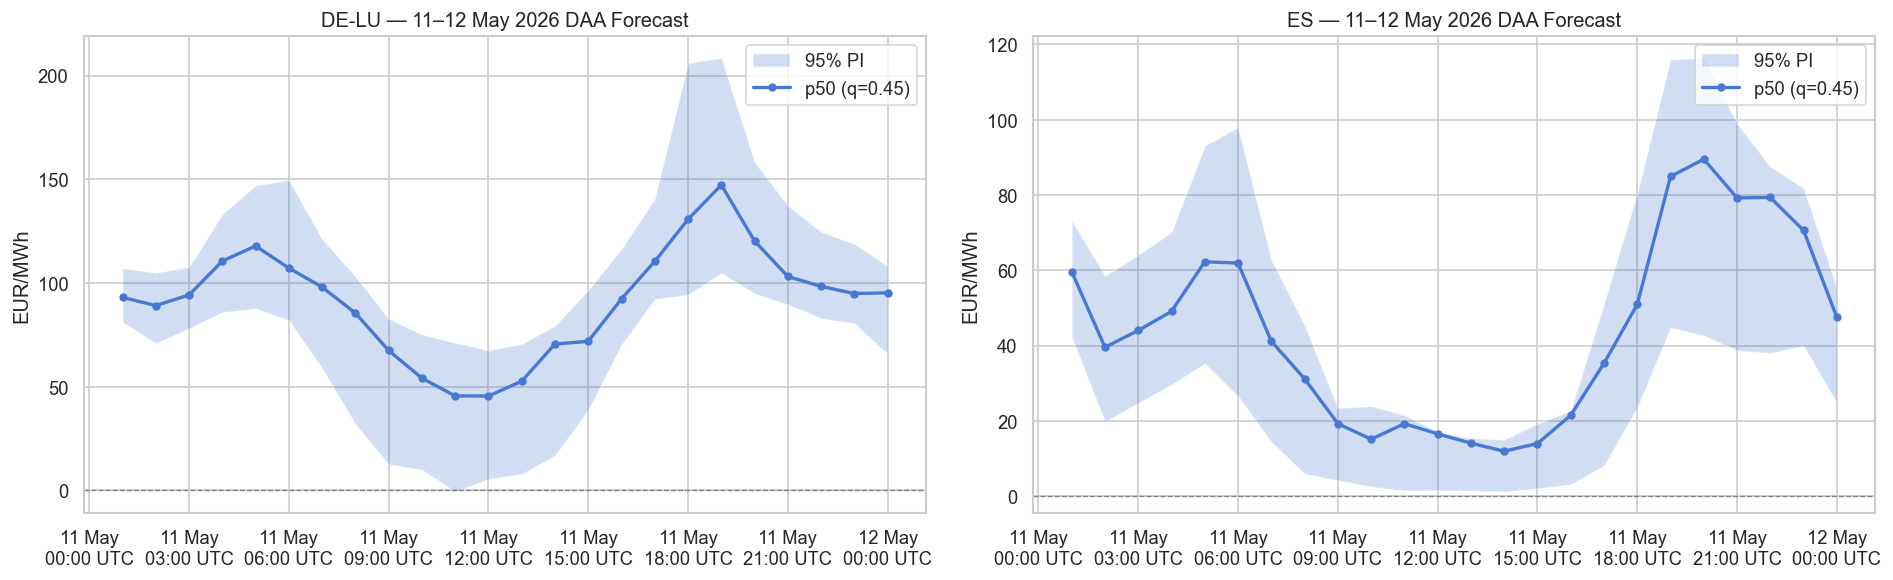

In [29]:
# Visualise evaluation window predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (zone, preds) in zip(axes, eval_preds.items()):
    t = preds.index
    ax.fill_between(t, preds['p025'], preds['p975'], alpha=0.25, label='95% PI')
    ax.plot(t, preds['p50'], marker='o', ms=4, lw=2, label='p50 (q=0.45)')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(f'{zone} — 11–12 May 2026 DAA Forecast')
    ax.set_ylabel('EUR/MWh')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:00 UTC'))

plt.tight_layout()
plt.show()

---
## 12 · Save Predictions CSV

In [30]:
def format_cet(ts_utc: pd.Timestamp) -> str:
    """Format UTC timestamp as CET string (+01:00), matching evaluation spec."""
    cet = ts_utc + pd.Timedelta(hours=1)
    return cet.strftime('%Y-%m-%dT%H:%M:%S+01:00')


rows = []
for ts in EVAL_TIMESTAMPS:
    de = eval_preds['DE-LU'].loc[ts]
    es = eval_preds['ES'].loc[ts]
    rows.append({
        'timestamp':   format_cet(ts),
        'DE-LU p025':  round(float(de['p025']), 2),
        'DE-LU p50':   round(float(de['p50']),  2),
        'DE-LU p975':  round(float(de['p975']), 2),
        'ES p025':     round(float(es['p025']), 2),
        'ES p50':      round(float(es['p50']),  2),
        'ES p975':     round(float(es['p975']), 2),
    })

out_df = pd.DataFrame(rows)
out_df.to_csv('predictions.csv', index=False)

print(f'Saved {len(out_df)} rows to predictions.csv')
print()
print(out_df.to_string(index=False))

Saved 24 rows to predictions.csv

                timestamp  DE-LU p025  DE-LU p50  DE-LU p975  ES p025  ES p50  ES p975
2026-05-11T02:00:00+01:00       81.27      93.09      107.19    42.38   59.64    73.21
2026-05-11T03:00:00+01:00       70.96      89.15      104.94    19.84   39.59    58.56
2026-05-11T04:00:00+01:00       78.21      94.24      107.67    24.81   44.03    64.10
2026-05-11T05:00:00+01:00       86.00     110.60      133.26    29.68   49.11    70.13
2026-05-11T06:00:00+01:00       87.79     117.88      147.01    35.29   62.28    93.11
2026-05-11T07:00:00+01:00       82.05     107.22      149.67    26.60   61.94    97.98
2026-05-11T08:00:00+01:00       58.96      98.06      121.16    14.44   41.18    62.87
2026-05-11T09:00:00+01:00       31.96      85.51      103.22     6.03   31.19    45.36
2026-05-11T10:00:00+01:00       12.67      67.48       82.74     4.25   19.30    23.44
2026-05-11T11:00:00+01:00       10.06      54.15       75.22     2.55   15.15    23.90
2026-05-1

In [31]:
# Sanity checks on the output file
df_check = pd.read_csv('predictions.csv')

assert len(df_check) == 24, f'Expected 24 rows, got {len(df_check)}'
assert list(df_check.columns) == [
    'timestamp', 'DE-LU p025', 'DE-LU p50', 'DE-LU p975',
    'ES p025', 'ES p50', 'ES p975'
], 'Column mismatch'
assert df_check.isna().sum().sum() == 0, 'NaN values found'

ts_series = pd.to_datetime(df_check['timestamp'])
diffs = ts_series.diff().iloc[1:]
assert (diffs == pd.Timedelta('1h')).all(), 'Timestamps not hourly monotone'

# Verify timestamps cover the correct window
assert ts_series.iloc[0] == pd.Timestamp('2026-05-11T02:00:00+01:00'), \
    f'Wrong start: {ts_series.iloc[0]}'
assert ts_series.iloc[-1] == pd.Timestamp('2026-05-12T01:00:00+01:00'), \
    f'Wrong end: {ts_series.iloc[-1]}'

# Check quantile monotonicity
for zone_prefix in ['DE-LU', 'ES']:
    ok = (
        (df_check[f'{zone_prefix} p025'] <= df_check[f'{zone_prefix} p50']) &
        (df_check[f'{zone_prefix} p50']  <= df_check[f'{zone_prefix} p975'])
    ).all()
    assert ok, f'Quantile monotonicity violated for {zone_prefix}'

print('All sanity checks passed ✓')
print(df_check[['DE-LU p025','DE-LU p50','DE-LU p975','ES p025','ES p50','ES p975']].describe().round(2))

All sanity checks passed ✓
       DE-LU p025  DE-LU p50  DE-LU p975  ES p025  ES p50  ES p975
count       24.00      24.00       24.00    24.00   24.00    24.00
mean        60.20      91.53      118.20    19.92   44.09    58.81
std         34.55      26.35       38.06    16.20   24.97    33.38
min         -0.59      45.54       67.58     1.21   11.97    15.01
25%         28.19      71.59       93.08     3.03   19.29    23.26
50%         74.58      94.60      112.38    21.72   42.60    60.72
75%         86.45     108.03      138.16    35.99   62.02    83.26
max        104.91     147.29      208.57    44.87   89.53   116.44
